# Seminar: From State Space Models to Mamba
## Bar Cohen, David Schneider
### Reichman University, CS MSc - LLMs and Information Theory Seminar

A structured overview of State Space Models (SSMs), their evolution, and how Mamba introduces Selective SSMs to overcome key limitations.

# 📘 Notebook Summary: From State Space Models to Mamba
This notebook, titled "From State Space Models to Mamba", presents a structured and comprehensive overview of State Space Models (SSMs) and their role as a compelling alternative to Transformer architectures in large language models.

It begins by exploring the limitations of Transformers, particularly their quadratic complexity in time and memory, which hinders performance on long sequences and structured signals (e.g., audio, genomics). The notebook then introduces SSMs as an efficient sequence modeling approach, breaking down the theory, mechanics, and implementation of linear SSMs.

Building on this foundation, the presentation culminates in Mamba, a novel architecture that enhances traditional SSMs with selective state updates and hardware-efficient design. It balances expressivity and efficiency, enabling scalable training on long sequences.

The notebook integrates explanations, visual diagrams, and code examples, and is designed to serve both as an educational resource and a live demo for a seminar presentation at Reichman University's CS MSc program.


## 🌍 Why Go Beyond Transformers?

Foundation models — from GPT and PaLM to Stable Diffusion — are almost universally built on **Transformers**.  
At their core is the **attention mechanism**, which enables powerful context reasoning... but at a cost:

- ❌ **Quadratic time & memory** with respect to sequence length  
- ❌ **Inefficient inference** for streaming or long-context inputs  
- ❌ Poor performance on structured signals (e.g., long audio, genomics)

To address this, researchers have explored **subquadratic alternatives** like:
- Linear attention
- Gated CNNs
- Recurrent models
- Structured State Space Models (**SSMs**)

Yet historically, these architectures have **underperformed Transformers** — especially on **language modeling**, where attention-based reasoning is crucial.

---

## 🔁 The Mamba Breakthrough

**Mamba** is a new architecture that **fixes the key weakness** of earlier SSMs:  
→ their inability to **selectively propagate or forget information** based on content.

🔑 **Key innovations:**
1. **Input-dependent SSM parameters**: Enables content-based reasoning (like attention)  
2. **Parallel hardware-aware implementation**: Retains linear-time efficiency  
3. **Simplified architecture**: No attention

---

### ⚡ Why Mamba Matters

| Feature                    | Transformer              | Mamba                         |
|----------------------------|--------------------------|-------------------------------|
| Sequence complexity        | O(n²)                    | O(n) ✅                        |
| Real-time streaming        | Slow ❌                   | Fast ✅                        |
| Handles long sequences     | Up to 2K–32K              | Up to **1M+** ✅              |
| Content-based reasoning    | ✅                        | ✅ (via selective SSMs)       |
| Inference throughput       | Baseline                 | **5× faster** ✅              |

---

### 🧪 Results Snapshot
- Mamba-3B **outperforms same-size Transformers** on language modeling
- Matches Transformers **twice its size** on both pretraining and downstream tasks
- Sets new benchmarks across **language, audio, and genomics**

> **Bottom line**: Mamba combines the best of both worlds — **efficiency of recurrence** and **intelligence of attention** — all in a simplified, high-speed, scalable architecture.


## Introduction

The term **state space model (SSM)** has a very broad meaning and simply represents the notion of any recurrent process with a latent (hidden) state. State space models are mathematical frameworks used to describe dynamic systems, systems that evolve over time - by maintaining an internal state that summarizes all relevant information from the past. At each step, the system receives an input, updates its internal state, and produces an output.

This general framework is used across many disciplines, often with different names and applications:
- **Markov Decision Processes (MDP):**
- **Dynamic Causal Modeling (DCM):**
- **Kalman Filters:** Control theory and signal processing
- **Hidden Markov Models (HMM):** Machine learning and statistics
- **Linear Dynamical Systems (LDS):** Machine learning and time series analysis
- **Recurrent Neural Networks (RNN):** Deep learning

Despite the diversity, these models share the same core idea:  
> The system maintains a hidden state, which is updated over time as new inputs arrive, and the output depends on both the state and the input.


In classic control theory, these are often written in continuous time as differential equations, or in discrete time as difference equations.

---

**In This Lecture:**  
We will focus on the **RNN perspective** of state space models, where the SSM is used as a generalization of recurrent neural networks for modeling sequences in deep learning.

---

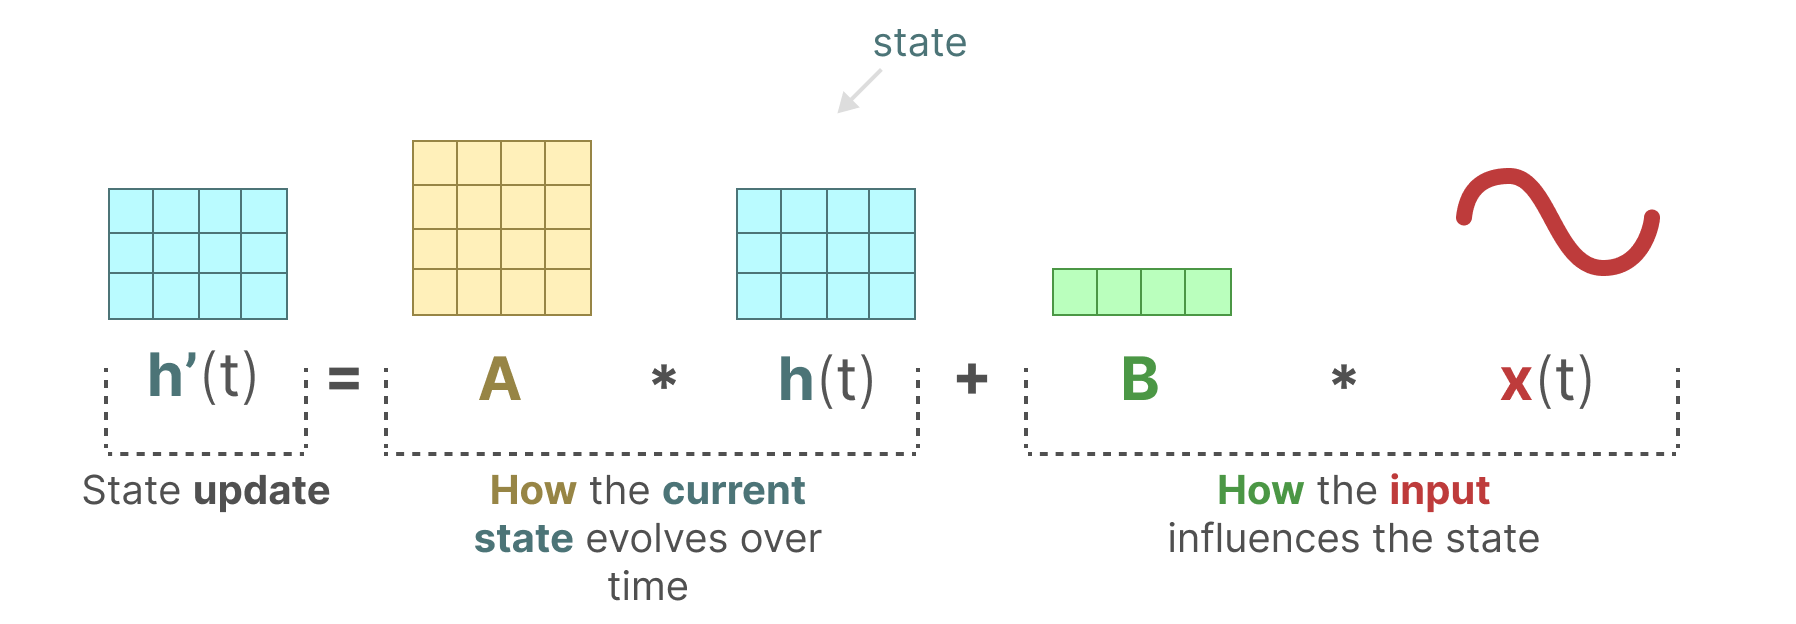

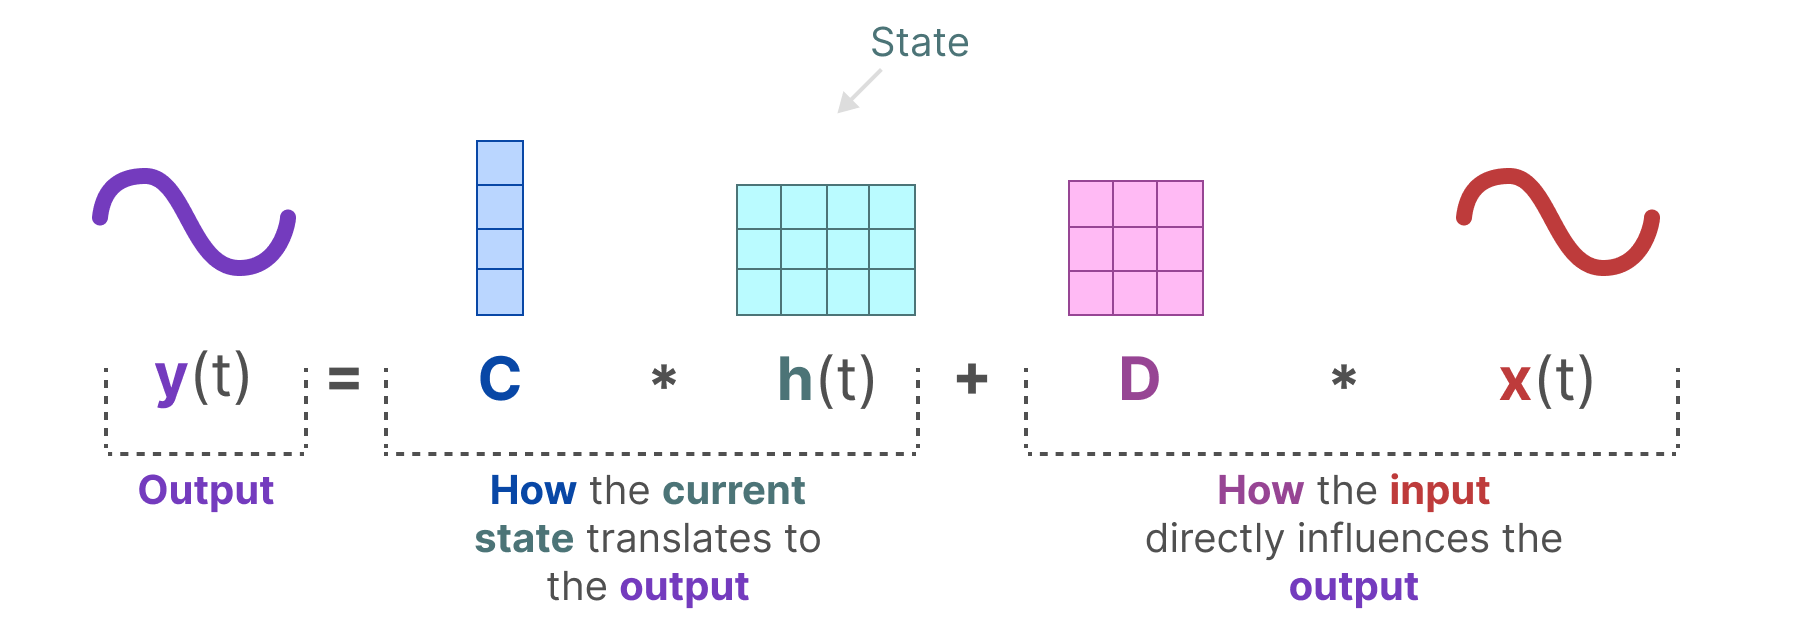

## 📘 State Space Model: Matrix Roles

A **State Space Model (SSM)** describes the evolution of a system using two key equations:

$$
\begin{aligned}
x_{t+1} &= A x_t + B u_t \\
y_t &= C x_t + D u_t
\end{aligned}
$$

Where:

- \$( x_t \in \mathbb{R}^n \)$ is the **hidden state vector** at time \( t \)

- \$( u_t \in \mathbb{R}^m \)$ is the **input vector**

- \$( y_t \in \mathbb{R}^p \)$is the **output vector**

### 📐 Matrix Roles

- **\$ A \in \mathbb{R}^{n \times n} \$:  
  The state transition matrix** — defines how the current state evolves to the next state in the absence of input.

- $ B \in \mathbb{R}^{n \times m} $:  
  The **control matrix** — determines how the control input $u_t$ affects the state transition.

- $C \in \mathbb{R}^{p \times n}$:  
  The **output matrix** — maps the internal state to the output.

- $D \in \mathbb{R}^{p \times m} $:  
  The **command matrix** — directly maps the control input to the output.



## Discretization of Continuous-Time State Space Models

In fact, each matrix \( A, B, C, D \) in the continuous-time state space model undergoes a **discretization process** (which we won't dive into here), resulting in a discrete-time system with the following form:

$$
\begin{aligned}
x_t &= \bar{A} x_{t-1} + \bar{B} u_t \\
y_t &= \bar{C} x_t + \bar{D} u_t
\end{aligned}
$$

where:
- $ \bar{A}, \bar{B}, \bar{C}, \bar{D} $ are the **discretized** system matrices.

---

## Perspectives on the Discrete-Time State Space Model

We can observe and interpret this discrete-time system from **three different perspectives**:

1. **Continuous-time perspective**:  
   The original system described by differential equations before discretization.

2. **Recurrent (RNN) perspective**:  
   The system as a recurrence relation updating hidden states over time, akin to an RNN
   
3. **Convolutional perspective**:  
   The system as a convolution operation where the output can be expressed as a convolution between the input sequence and an impulse response derived from the system matrices.

---

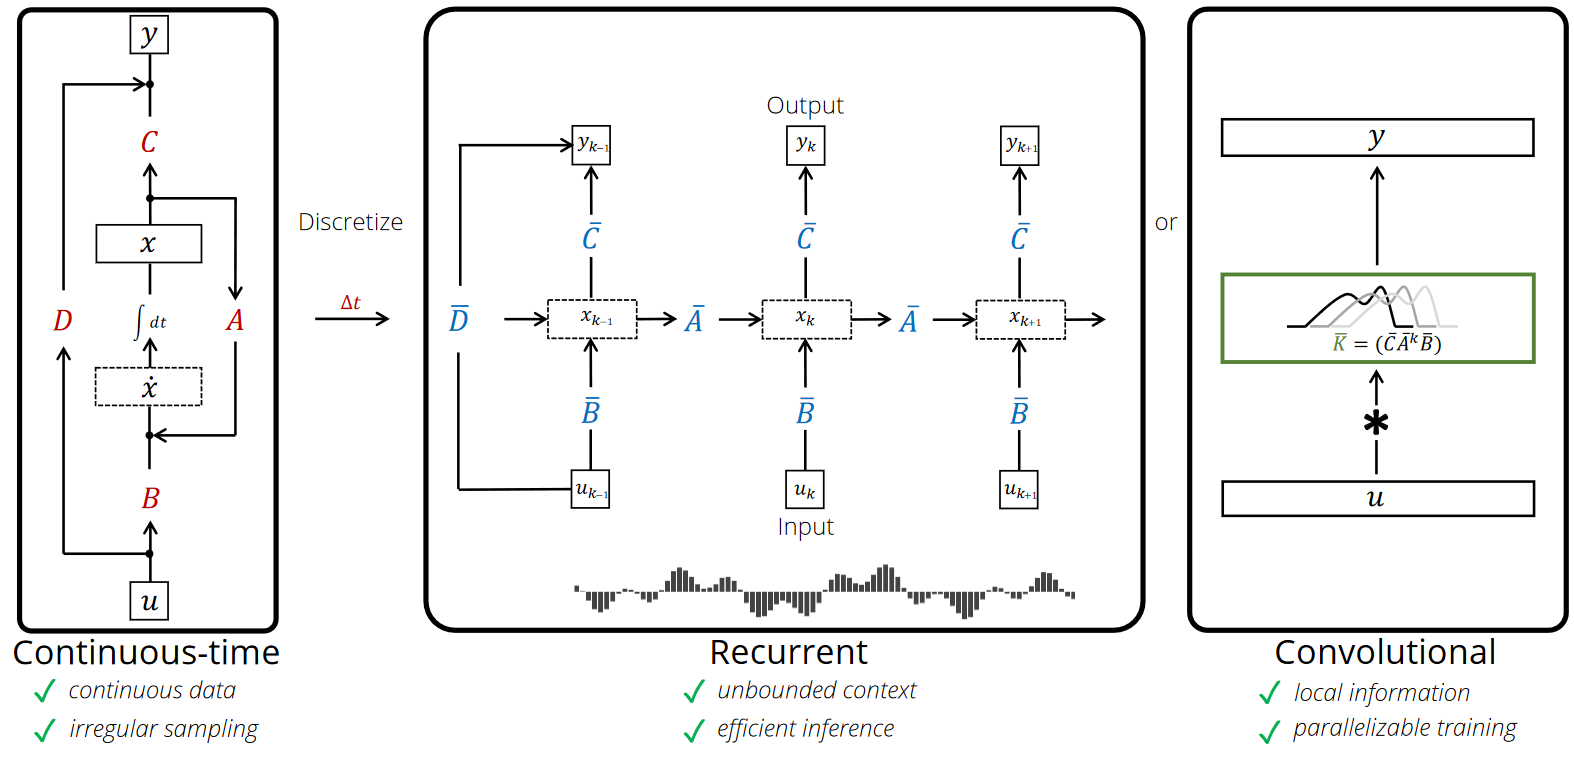

In [6]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from typing import Optional, Tuple
import math

# Check for Apple Silicon (M1/M2/M3) GPU
if hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
    device = torch.device("mps")
# Fall back to CUDA if available
elif torch.cuda.is_available():
    device = torch.device("cuda")
# Otherwise use CPU
else:
    device = torch.device("cpu")
print(f"Using device: {device}")

Using device: mps


In [7]:
# Basic SSM Implementation

class BasicSSM(nn.Module):
    def __init__(self, state_dim, input_dim, output_dim):
        super().__init__()

        # Learnable parameters (initialized near identity or small random)
        self.A = nn.Parameter(torch.eye(state_dim) + 0.01 * torch.randn(state_dim, state_dim))
        self.B = nn.Parameter(0.1 * torch.randn(state_dim, input_dim))
        self.C = nn.Parameter(0.1 * torch.randn(output_dim, state_dim))
        self.D = nn.Parameter(torch.zeros(output_dim, input_dim))


    def forward(self, x0, inputs):
        """
        Forward pass through the state space model.
        Args:
            x0: initial state (batch_size, state_dim)
            inputs: input sequence (batch_size, T, input_dim)
        Returns:
            outputs: output sequence (batch_size, T, output_dim)
        """
        batch_size, T, input_dim = inputs.shape
        state_dim = x0.shape[1]
        output_dim = self.C.shape[0]

        x = x0
        outputs = []

        for t in range(T):
            u_t = inputs[:, t]  # shape: (batch_size, input_dim)
            y_t = x @ self.C.T + u_t @ self.D.T
            outputs.append(y_t)
            x = x @ self.A.T + u_t @ self.B.T

        return torch.stack(outputs, dim=1)  # (batch_size, T, output_dim)



## 🛩️ Airplane Motion Demo Using BasicSSM

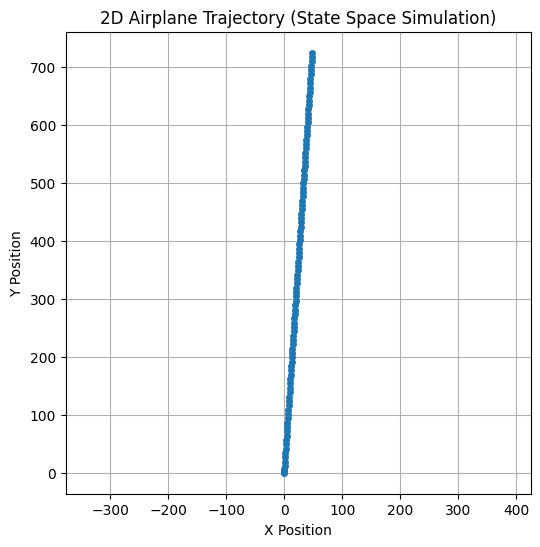

In [11]:
# ---- Create SSM model ----

state_dim = 4  # [x, y, vx, vy]
input_dim = 2  # [ax, ay]
output_dim = 2 # [x, y]

# ---- Override A, B, C with interpretable airplane dynamics ----
ssm = BasicSSM(state_dim, input_dim, output_dim)

A = torch.tensor([
    [1, 0, 1, 0],  # x' = x + vx
    [0, 1, 0, 1],  # y' = y + vy
    [0, 0, 1, 0],  # vx' = vx
    [0, 0, 0, 1],  # vy' = vy
], dtype=torch.float32)

B = torch.tensor([
    [0.5, 0],      # x' += 0.5 * ax
    [0, 0.5],      # y' += 0.5 * ay
    [1.0, 0],      # vx' += ax
    [0, 1.0],      # vy' += ay
], dtype=torch.float32)

C = torch.tensor([
    [1, 0, 0, 0],  # output x
    [0, 1, 0, 0],  # output y
], dtype=torch.float32)

D = torch.zeros((2, 2))  # no feedthrough

# Apply to model
with torch.no_grad():
    ssm.A.copy_(A)
    ssm.B.copy_(B)
    ssm.C.copy_(C)
    ssm.D.copy_(D)

# ---- Simulate: constant thrust for first 5 steps ----

T = 20
inputs = torch.zeros(1, T, input_dim)
inputs[:, :5, 0] = 0.1  # light x acceleration
inputs[:, :5, 1] = 1.5  # strong y acceleration

x0 = torch.zeros(1, state_dim)
outputs = ssm(x0, inputs)

# ---- Plot the 2D trajectory ----

x = outputs[0, :, 0].detach().numpy()
y = outputs[0, :, 1].detach().numpy()

plt.figure(figsize=(6, 6))
plt.plot(x, y, marker='o', markersize=4)
plt.title("2D Airplane Trajectory (State Space Simulation)")
plt.xlabel("X Position")
plt.ylabel("Y Position")
plt.grid(True)
plt.axis("equal")
plt.show()


## Linear Time-Invariant (LTI) State Space Models and Their Connection to RNNs

### What are LTI (Linear Time-Invariant) SSMs? How Are They Different from Classic RNNs?

**Linear Time-Invariant (LTI) State Space Models** are a special class of state space models where the parameters governing the system's evolution - namely matrices \(A\), \(B\), and \(C\)—are **fixed and do not change over time** or with the input. The system is called "linear" because all updates are linear functions of the state and input, and "time-invariant" because the update rules are the same at every time step.


**How are LTI SSMs different from classic RNNs?**
- **Classic RNNs** (including LSTMs and GRUs) use **nonlinearities** (e.g., tanh, sigmoid, ReLU) in their state updates, and often use gates that depend on the current input and sometimes the previous output.
- **LTI SSMs** are **purely linear** and have no nonlinearity between hidden states or outputs. This linearity allows for certain mathematical tricks (like convolutional and scan representations) and efficient parallelization.
- In summary:  
  - **LTI SSM:** Linear, time-invariant, no nonlinearity, parameters fixed for all steps  
  - **RNN:** Usually nonlinear, can be time-varying (parameters or gates can depend on input), more flexible for modeling complex dynamics

---

### Why LTI SSMs Are Great for Inference — But Less Ideal for Training

**LTI State Space Models** offer a key advantage during inference:  
They enable **constant-time per-token computation**. That means:

- At inference time, we generate one token at a time.
- The computation required to generate token $i$ is exactly the same as the computation for token $j$.
- This makes LTI SSMs efficient and appealing for **auto-regressive generation**, similar to how RNNs operate.

---

However, during **training**, we already have access to the **entire input and output sequences**. There is **no need to generate outputs sequentially**, one at a time. Instead:

- We want to **process the whole sequence in parallel** to maximize efficiency.
- RNN-style sequential recurrence is a bottleneck here because it prevents parallelism.
- Even though RNNs (and basic SSMs) can model temporal dependencies well, they are **computationally inefficient** for training on modern hardware like GPUs.

---

### 🔁 From Recurrence to Convolution: Understanding LTI State Space Models


A **Linear Time-Invariant (LTI) State Space Model** is a type of dynamical system defined by the following equations:


\begin{aligned}
s_{t+1} &= A\,s_t \;+\; B\,x_t \\
y_t     &= C\,s_t
\end{aligned}


Where:
- \$(x_t \in \mathbb{R}^m\)$: input vector at time \(t\)

- \$(s_t \in \mathbb{R}^d\)$: hidden state vector at time \(t\)

- \$(y_t \in \mathbb{R}^n\)$: output vector at time \(t\)  

- \$(A\in\mathbb{R}^{d\times d}\), \(B\in\mathbb{R}^{d\times m}\), \(C\in\mathbb{R}^{n\times d}\)$: fixed learned matrices

We assume an initial state \( s_0 = 0 \). This model updates its state recursively and produces output from the current state.

---

#### 2. Step-by-step Unrolling Example

Suppose:

- Input sequence: \$( x = [x_0, x_1, x_2, x_3] \)$

We compute each step as follows:

- **t = 0**:
  \[
  $s_1 = B x_0,\quad y_0 = C s_0 = 0$
  \]

- **t = 1**:
  \[
 $ s_2 = A s_1 + B x_1 = A B x_0 + B x_1,\quad y_1 = C s_1 = C B x_0$
  \]

- **t = 2**:
  \[
  $s_3 = A^2 B x_0 + A B x_1 + B x_2,\quad y_2 = C s_2 = C A B x_0 + C B x_1$
  \]

You can see how each output is a **weighted sum of past inputs**.

---

#### 3. General Pattern

From the unrolling, we observe the output at time \( t \) is:


$
y_t = \sum_{i=1}^{t} C A^{i-1} B \cdot x_{t - i}
 $

Let us define the **convolution kernel**:


$K_i = C A^i B$


So the output becomes:


$y_t = \sum_{i=0}^{t} K_i \cdot x_{t - i}$


This is exactly the definition of a **causal 1D convolution** of the input sequence \( x \) with the kernel \( K \).

---

#### 4. Parallel Computing of the Convolution

This convolutional form has a major computational benefit:

- **Sequential recurrence** requires each $ s_t $ to be computed step-by-step (not parallelizable).
- But **convolution** can be computed in parallel across time using:
  - Matrix multiplication (e.g., via a Toeplitz matrix)
  - Efficient convolution routines (`conv1d` in PyTorch, TensorFlow, etc.)
  - FFT-based convolution (fast for long sequences)

Thus, even though the original SSM is defined as a recurrence, in the **linear time-invariant** case, we can **transform it into a convolution**, which enables efficient parallelization on modern hardware (e.g., GPUs).

---

Thus far, all structured SSMs have been LTI (e.g. computed as convolutions) because of fundamental efficiency constraints. However, a core insight of this work is that LTI models have fundamental limitations in modeling
certain types of data, and Mamba's technical contributions involve removing the LTI constraint while overcoming the efficiency
bottlenecks.

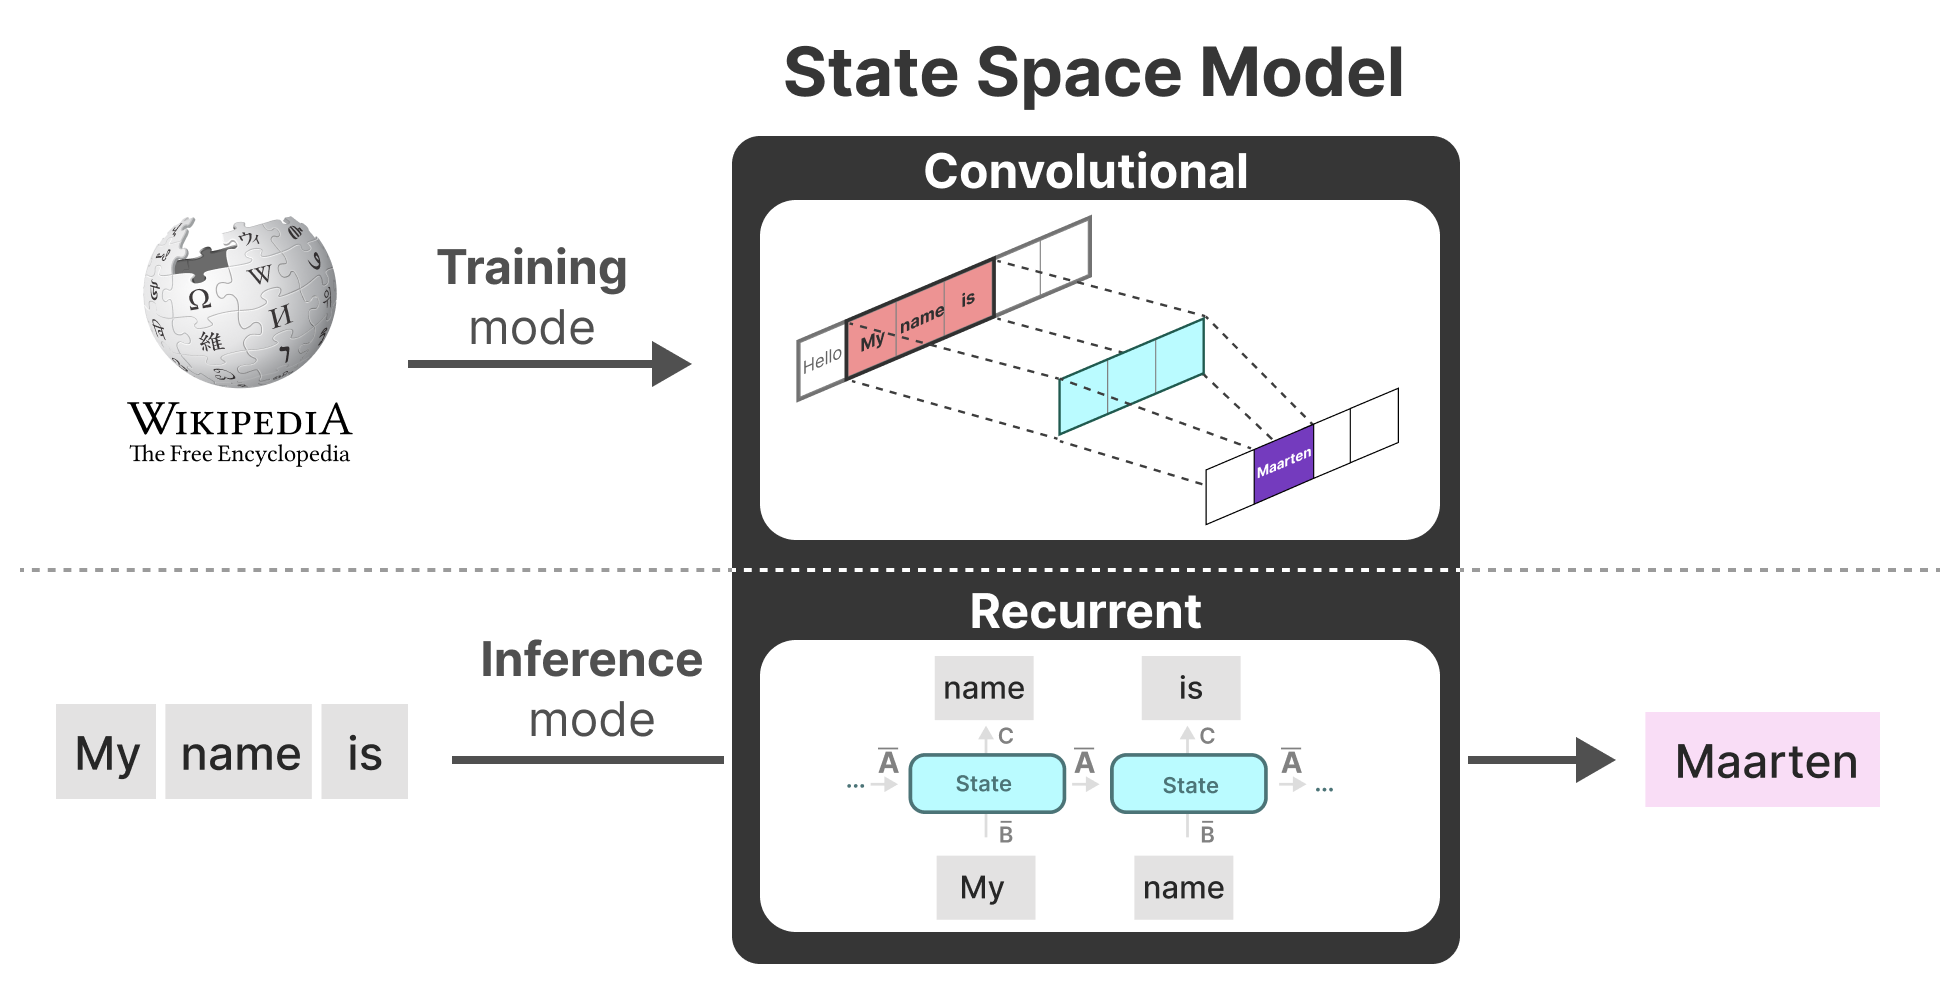

### ❌ The Problem with Traditional LTI State Space Models

State space models are a powerful way to represent sequential data, but traditional **Linear Time-Invariant (LTI)** formulations have several limitations when used in modern learning systems, especially when applied to long sequences.

---

#### 1. **Same Matrix Across All Time Steps and Inputs**

In LTI systems, the transition matrix $A$ and the other matrices ($B, C, D$) remain **fixed** for all time steps and inputs:

$
x_t = A x_{t-1} + B u_t \\
y_t = C x_t + D u_t
$

This means the system **cannot adapt dynamically** to varying input patterns or positions in the sequence. For long and diverse sequences (e.g. language, video), using a **shared static operator** across all time steps can severely limit expressiveness.

---

#### 2. **Vanishing / Exploding Gradients**

Just like in vanilla RNNs, gradients must propagate through time via repeated matrix multiplications:

$
x_t = A^t x_0 + \sum_{k=0}^{t-1} A^{t-k-1} B u_k
$

When training with gradient descent, repeated multiplication by $A$ leads to:

- **Vanishing gradients** if the eigenvalues of $A$ are < 1
- **Exploding gradients** if the eigenvalues of $A$ are > 1

This makes optimization unstable or ineffective, especially for **long-term dependencies**.

---

#### 3. **Representation Bottleneck in a Single Hidden State**

All past information must be represented into a **single state vector** $x_t \in \mathbb{R}^n$. This creates a strong **information bottleneck**:

- The state must store **all relevant history**, which is especially hard when the signal contains long-range dependencies.
- There’s **no explicit memory** or attention — the system must “remember” by shaping the latent dynamics through $A$.

---

These limitations motivate modern extensions, such as:
- Learnable **time-varying** parameters
- Replacing hidden states with **structured memory**
- Selective or adaptive state transitions



### 🧪 Two Illustrative Tasks

To demonstrate the limitations of classical models and the need for **selectivity**, consider these synthetic tasks:

#### 1. 🟩 Selective Copying Task
- A variant of the standard copying task.
- Requires the model to **memorize only selected (colored) tokens**, ignoring others.
- Demands **content-aware** reasoning: the model must know **what** to remember and **when**.

#### 2. ⚫ Induction Heads Task
- Simulates how LLMs perform **in-context learning**. (One-shot prompting).
- The model must know when to **trigger** the correct response based on the **surrounding context**.

These tasks **break traditional LTI models**:
- **Recurrent view**: Fixed dynamics (\(A, B\)) can't select relevant info.
- **Convolutional view**: Static convolution kernels can't handle **variable spacing** between relevant tokens.

---

### 📚 The Efficiency vs. Effectiveness Tradeoff

| Model Type       | State Size   | Inference Speed | Context Compression | Limitation                          |
|------------------|--------------|------------------|---------------------|-------------------------------------|
| Transformers     | Large (KV)   | Slow             | None                | High memory and compute costs       |
| RNNs / LTI SSMs  | Small        | Fast             | Poor                | Hard to model long or content-based dependencies |



## What are Selective State Space Models?

Selective State Space Models (SSSMs) are a modern extension of classical State Space Models (SSMs), designed to overcome key limitations of **Linear Time-Invariant (LTI)** systems in deep learning.

---

### 🌟 Core Idea


**Selective SSMs** make the dynamics **input-dependent** by using:
- **Dynamic, per-step parameters** (especially in the state transition matrix)
- **Multiplicative gating**
- **Non-linear projections**

This allows the model to **selectively update** parts of the hidden state at each time step, based on the current input and context.

## 🔧 Improving State Space Models with Selection

### 🧠 Key Idea: Make Parameters Input-Dependent

To enable **context-aware selection** in State Space Models (SSMs), we can **dynamically vary the model's internal parameters based on the input**.

---

### 🔁 From Time-Invariant to Time-Varying

By making $ \Delta, B, C $ functions of the input $ x $, we transform the model into a **time-varying** system:

- Parameters now **change across the sequence length \( L \)**.
- This breaks the convolutional interpretation (since convolutions rely on static kernels).
- However, it enables **context-dependent recurrence**, allowing the model to **selectively propagate** important information.

---

### ⚙️ Implementation Strategy

Let the input-dependent parameter functions be:

- $ s_B(x) = \text{Linear}_N(x) $
- $ s_C(x) = \text{Linear}_N(x) $
- $ s_\Delta(x) = \text{Broadcast}_D(\text{Linear}_1(x)) $

These are simple **feed-forward projections**, and they allow the model to **adaptively generate**:

-  $ \Delta $: The update rates for how the resolution of the input should change (the discretization parameter)
- $ B $: The way inputs influence the state
- $C$: The way state affects outputs

**Note:** Matrix A remains the same since we want the state itself to remain static but the way it is influenced (through B and C) to be dynamic

**Final Formula:**

$x_{t+1} = \bar A_tx_t + \bar B_t u_t$

$y_t = C_tx_t $

---

### 💡 Why This Matters

This **input-dependent parametrization** is analogous to **gating mechanisms in RNNs** (e.g., GRUs, LSTMs):

- Gating helps control **what information to let in or out** of the hidden state.
- In selective SSMs, this gating is implemented via **dynamic recurrence** and **input-aware selection**.

---

### 🚫 Tradeoff: Loss of Convolution Efficiency

Since the model now operates in a **time-varying** regime, the equivalence to **global convolutions** no longer holds.

- **Pros**: Gains context-awareness, flexibility, better performance on tasks like Selective Copying.
- **Cons**: Loses the fast parallelization that convolutional implementations provide.



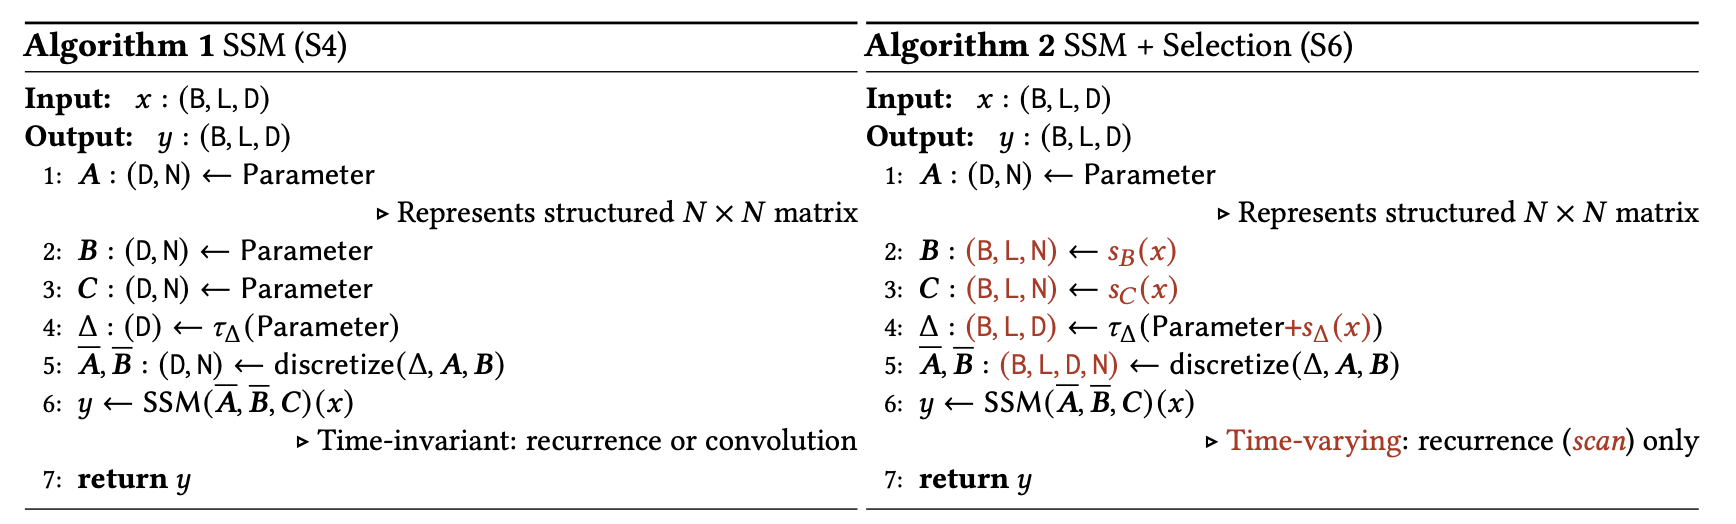

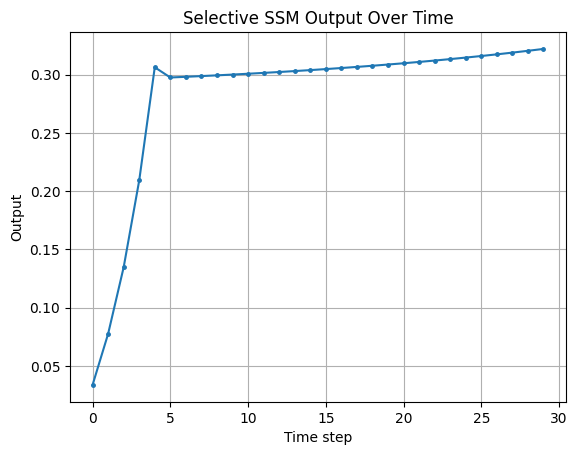

In [ ]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# Selective State Space Model
class SelectiveSSM(nn.Module):
    def __init__(self, input_dim, hidden_dim, seq_len):
        super().__init__()
        self.input_dim = input_dim
        self.hidden_dim = hidden_dim
        self.seq_len = seq_len

        # Learned projections
        self.s_B = nn.Linear(input_dim, hidden_dim)
        self.s_C = nn.Linear(input_dim, hidden_dim)
        self.s_Delta = nn.Linear(input_dim, 1)

        # Shared base A matrix
        self.A_base = nn.Parameter(torch.eye(hidden_dim))

    def discretize(self, A, B, delta):
        """
        Forward Euler discretization.
        A: (B, L, N, N)
        B: (B, L, N)
        delta: (B, L)
        """
        I = torch.eye(A.size(-1), device=A.device).unsqueeze(0).unsqueeze(0)
        A_disc = I + delta[..., None, None] * A
        B_disc = delta[..., None] * B
        return A_disc, B_disc

    def forward(self, x):
        """
        x: Input sequence (B, L, D)
        Returns: Output sequence (B, L)
        """
        B, L, D = x.shape
        N = self.hidden_dim

        B_tilde = self.s_B(x)          # (B, L, N)
        C_tilde = self.s_C(x)          # (B, L, N)
        delta = torch.relu(self.s_Delta(x)).squeeze(-1)  # (B, L)

        # Expand A across time and batch
        A = self.A_base.expand(B, L, N, N)

        A_disc, B_disc = self.discretize(A, B_tilde, delta)

        x_state = torch.zeros(B, N, device=x.device)
        outputs = []

        for t in range(L):
            A_t = A_disc[:, t]       # (B, N, N)
            B_t = B_disc[:, t]       # (B, N)
            C_t = C_tilde[:, t]      # (B, N)

            x_state = torch.bmm(A_t, x_state.unsqueeze(-1)).squeeze(-1) + B_t
            y_t = torch.sum(x_state * C_t, dim=-1)  # (B,)
            outputs.append(y_t)

        return torch.stack(outputs, dim=1)  # (B, L)


# ==== Run Example ====

torch.manual_seed(42)

batch_size = 1
seq_len = 30
input_dim = 4
hidden_dim = 8

# Generate input: a step input in the first feature
x_input = torch.zeros(batch_size, seq_len, input_dim)
x_input[:, 5:, 0] = 1.0  # Step signal in first input dim

# Create model and run forward
model = SelectiveSSM(input_dim=input_dim, hidden_dim=hidden_dim, seq_len=seq_len)
output = model(x_input)

# Plot the output
plt.plot(output.detach().cpu().numpy()[0], marker='.', markersize=5)
plt.title("Selective SSM Output Over Time")
plt.xlabel("Time step")
plt.ylabel("Output")
plt.grid(True)
plt.show()


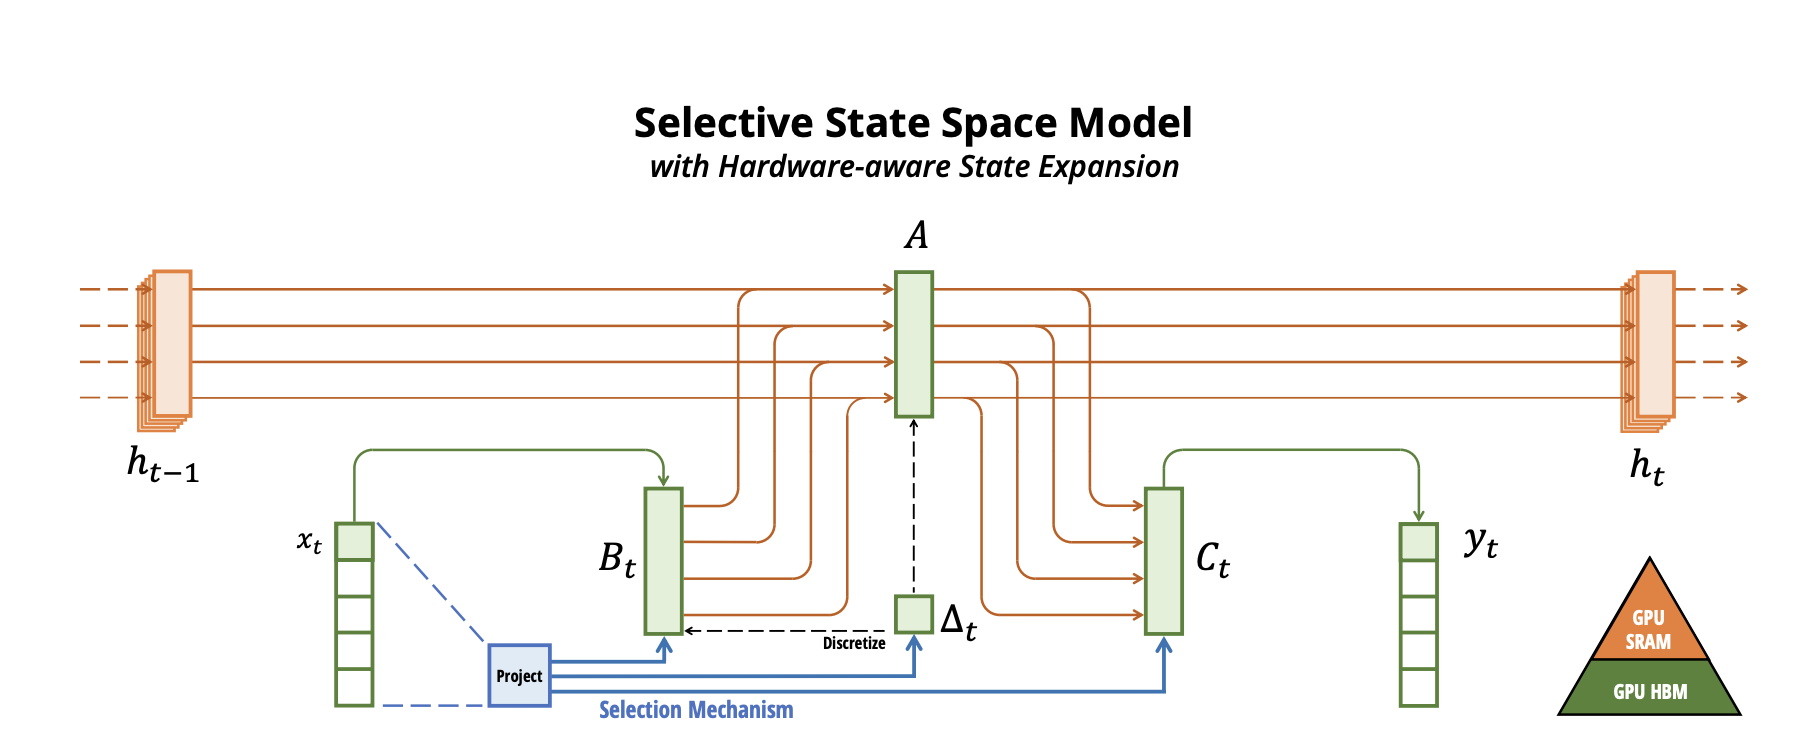

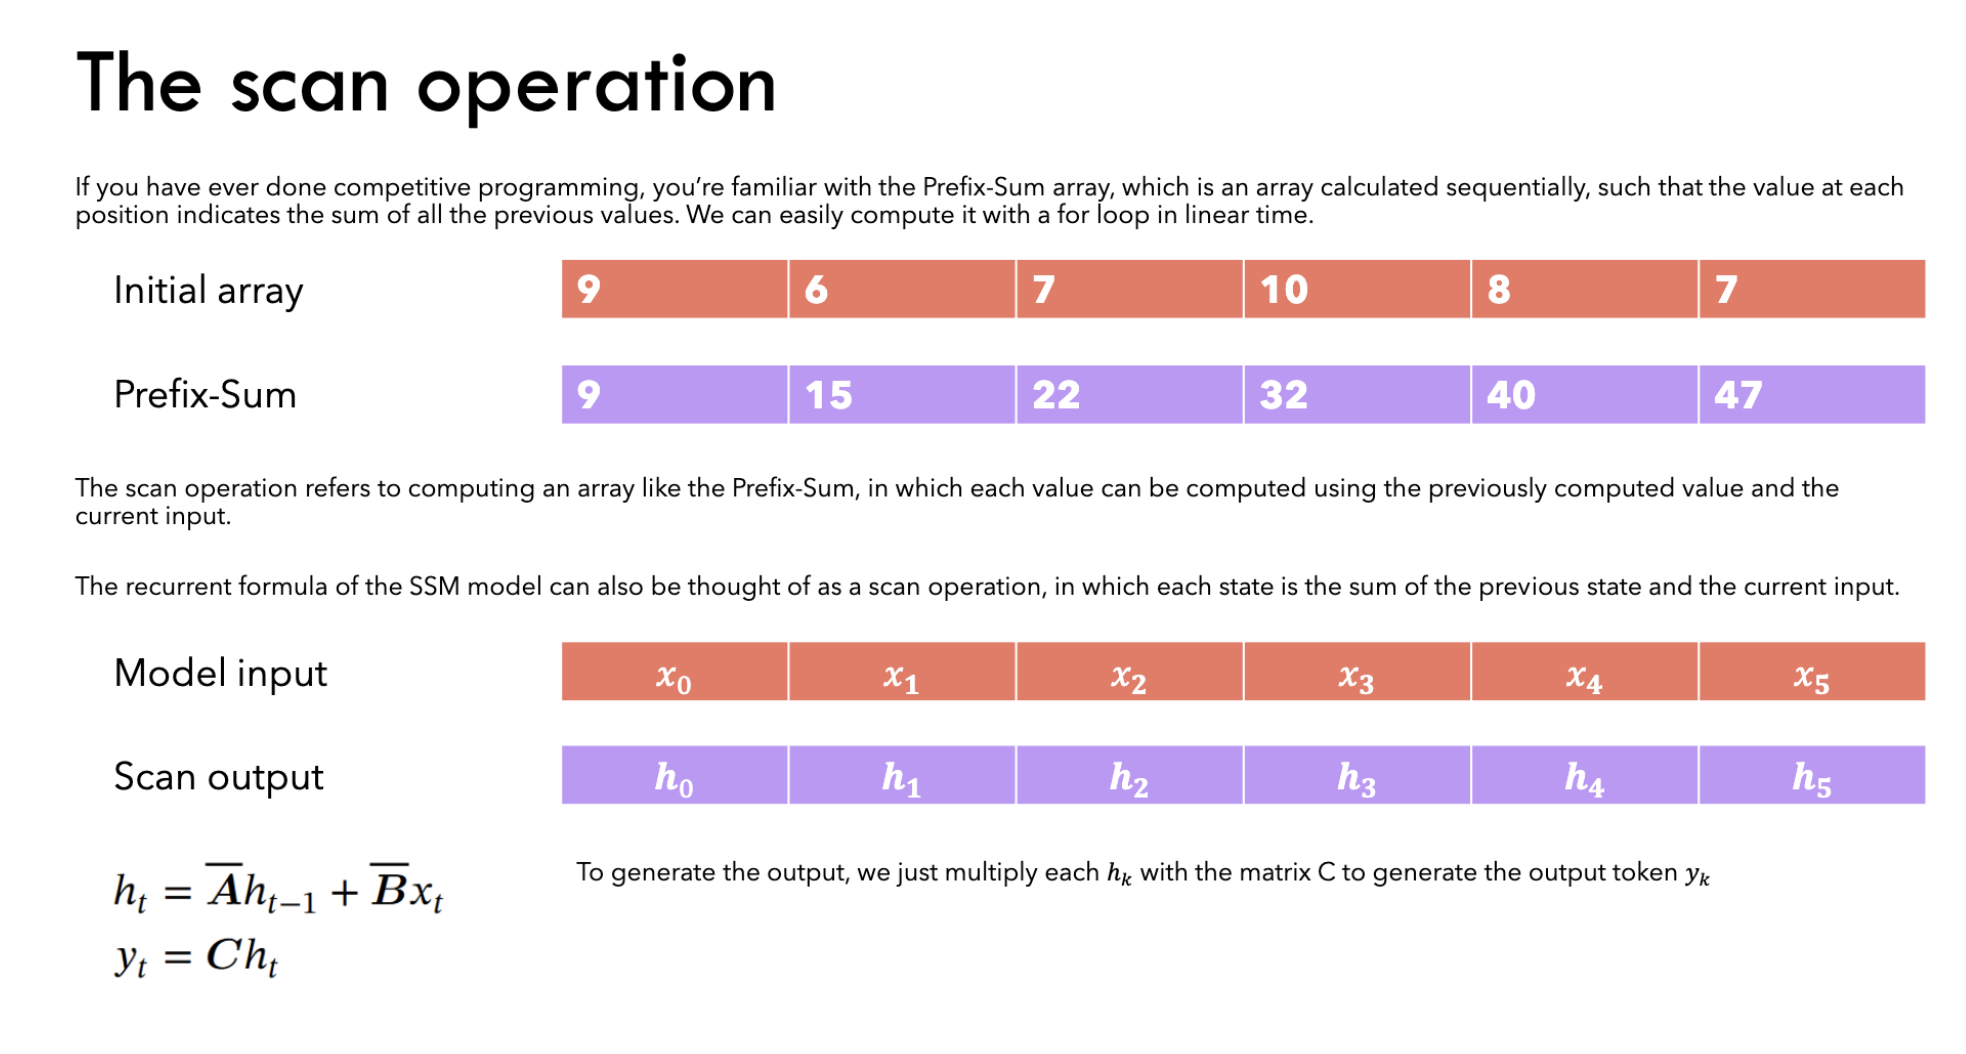

## Efficient Parallelization via the Scan Algorithm

### Parallel Time Complexity: $O(\log n)$

The scan algorithm (also known as prefix sum) is a powerful tool in parallel computing. It allows certain recurrences—like cumulative sums—to be computed in parallel, rather than sequentially.

The key insight is that if the underlying operation (e.g., addition) is **associative**, we can restructure the computation using a binary tree to perform it in $O(\log n)$ **parallel time**, using $O(n)$ processors.

This is achieved through two phases:

1. **Up-Sweep (Reduce)**: Build a binary tree of partial results in $O(\log n)$ levels.
2. **Down-Sweep (Distribute)**: Propagate the results downward to compute all prefix sums, again in $O(\log n)$.

Because operations on each level of the tree can be done in parallel, the overall depth of computation is logarithmic in the size of the input.

### Why This Matters for Selective State-Space Models

In traditional linear time-invariant (LTI) state-space models (like LSSL), the recurrence:

$$
h_t = A h_{t-1} + B x_t
$$

can be **unrolled** into a **convolution**, which allows the use of Fast Fourier Transforms (FFTs) for efficient computation.

However, in **Selective State-Space Models** (like Mamba), the recurrence is **data-dependent**:

$$
h_t = A h_{t-1} + B_t x_t
$$

Here, $B_t$ is not fixed—it depends on the input at time $t$, breaking time-invariance. As a result, the same convolution kernel **cannot be reused** across time steps.

Since we can no longer leverage FFT-based convolutions, we must resort to a different method: **parallel scan**.

The selective recurrence still has an **associative structure** (e.g., summing terms that depend on previous hidden states and inputs). This allows us to apply the **scan algorithm** to compute hidden states efficiently **in parallel**, overcoming the sequential bottleneck of naïve recurrence computation.

In summary:
- Selective SSMs are not time-invariant $\Rightarrow$ convolution is no longer applicable.
- But the recurrence is still associative $\Rightarrow$ scan algorithm can be used.
- Scan enables **$O(\log n)$ parallel time**, making it practical for long sequences and high-throughput training.


## A Simplified MAMBA Architecture

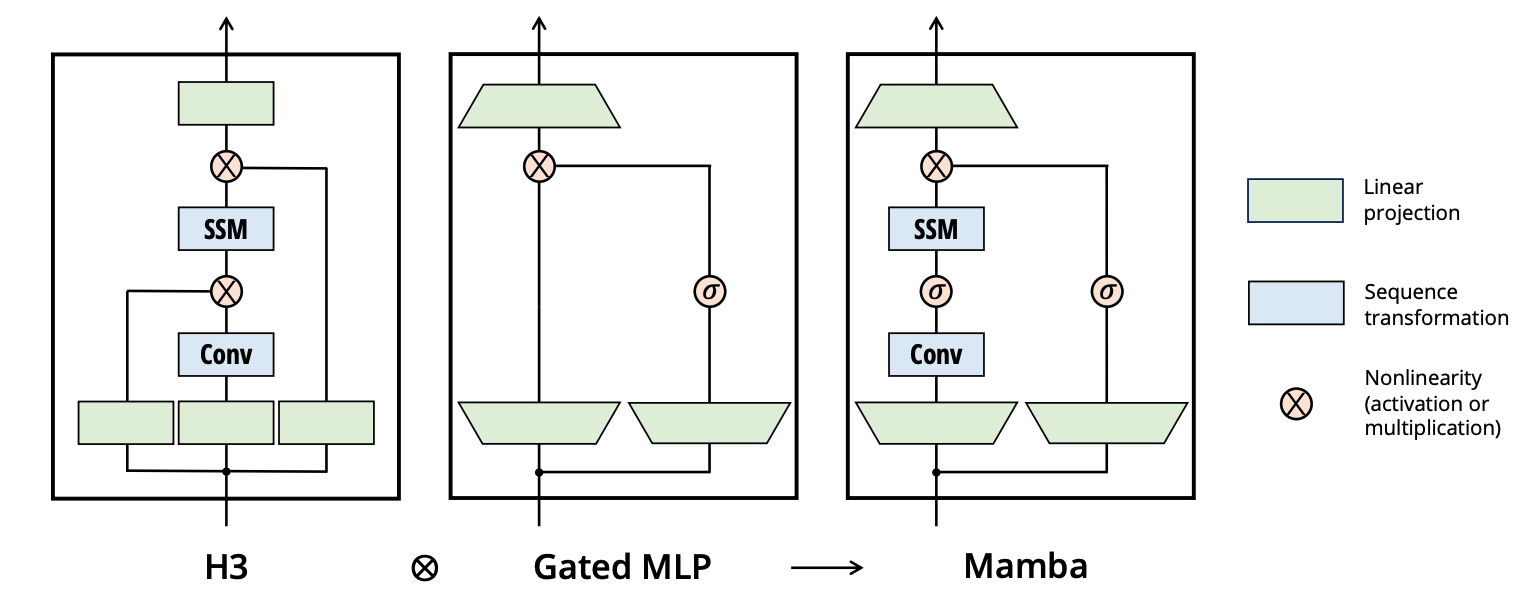


## 🔄 Mamba Block Architecture Explained

Selective State Space Models (SSMs) can be flexibly integrated into neural networks as **sequence transformation blocks**.  
The **Mamba architecture** simplifies and unifies attention-inspired mechanisms and feedforward blocks into a **homogeneous structure**.

### 🧱 Key Design: Simplified H3 Block (Inspired by GAU)

# - Based on the H3 architecture, which merges ideas from **linear attention** and **MLPs**.
- This version combines both into a single **Mamba block**, inspired by the **Gated Attention Unit (GAU)**.

---

### 🧩 Key Properties:

- 🔹 **Dimensional Expansion**: Input of dimension `D` is projected to `E×D` (typically, `E=2`) for gating and values.
- 🔹 **Parameter Efficiency**: Most weights are in **linear projections**; **SSM parameters** (Δ, A, B, C) are small and fixed-size.
- 🔹 **Modular Blocks**: Architecture stacks **multiple blocks** with residuals and (optional) normalization.
- 🔹 **Gating Activation**: Uses **SiLU (Swish)** for gating, similar to **SwiGLU**.
- 🔹 **Normalization**: Typically applies **LayerNorm** before processing.

---

### 🧠 Architecture Flow per Block:

1. **Linear Projection**:  
   Input → `[Gate, Value] = Linear(x)` → Shape: `(B, T, E×D)`
   
2. **Gating**:  
   Apply `SiLU` or `sigmoid` to gate → `Gate ⊙ Value`
   
3. **SSM Processing** (Optional):  
   The `Value` passes through the **Selective SSM** module (e.g., convolution or recurrence).
   
4. **Reprojection**:  
   `Linear(gated_output) → (B, T, D)`
   
5. **Residual & Norm**:  
   Output is added back to input (residual), with optional LayerNorm.

---

### 📏 Mamba vs Transformer

| Component       | Transformer         | Mamba Block                     |
|----------------|---------------------|---------------------------------|
| Attention       | Multi-Head Attention| Selective SSM (linear time)     |
| Gating          | No explicit gating  | SiLU-based dynamic gating       |
| Layers          | MHA + MLP per layer | Homogeneous SSM+MLP block       |
| Efficiency      | Quadratic (attention)| Linear in sequence length       |
| Parameters      | Spread across MHA/MLP| Mostly in linear layers         |

---

### 🔁 Summary

The **Mamba block**:
- Simplifies the architecture using gated projection + SSM.
- Enables fast, linear-time sequence modeling.
- Matches Transformer performance at scale while reducing complexity.


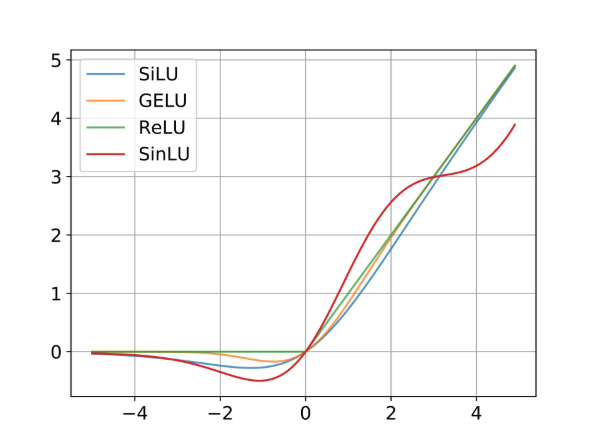

## 🔍 Properties of Selection Mechanisms

### ✅ What is a Selection Mechanism?

Selection in SSMs refers to **input-dependent control** over how much the system should:

* **update its internal state**, or
* **incorporate an input at all**.

This mechanism generalizes traditional gating in RNNs, and can be applied across models: RNNs, CNNs, and SSMs.

---

### 🔁 Selection as Gating

* **Key Insight**: Gating in RNNs is a special case of the SSM selection mechanism.
* A selective SSM becomes equivalent to a **gated RNN**:

$$
\begin{align*}
g_t &= \sigma(\text{Linear}(x_t)) \\
h_t &= (1 - g_t) \cdot h_{t-1} + g_t \cdot x_t
\end{align*}
$$

* This draws a connection between **continuous-time SSM discretization** and **discrete gating logic**.

---

### 🧠 What is Gating, Really?

A **gate** is a learned, data-dependent function that determines:

* How much of the input to allow into the computation.
* Whether to **retain memory** or **update it** at a given step.

It typically involves:

* A **linear transformation** of the input.
* A **nonlinear activation** (e.g. sigmoid or SiLU).
* An **element-wise multiplication** with a value signal.

In code, this often looks like:

```python
proj = Linear(x)         # → split into gate and value
gate, value = proj.chunk(2, dim=-1)
gate = sigmoid(gate)     # Or SiLU
output = gate * value    # Element-wise control
```

This mechanism gives the model **fine-grained control** over how much each token should contribute to the state or output.

---

### 📎 Why Selection and Gating Matter

Selective mechanisms enable powerful behaviors that fixed (non-selective) systems struggle with:

#### 1. **Variable Spacing**

* The model can **ignore irrelevant or noisy tokens**, e.g., language fillers like “uh”, “um”.
* Gating with \$g\_t \to 0\$ means “skip this input.”

#### 2. **Filtering Context**

* Many models **degrade** with long contexts because they can't ignore unneeded history.
* Selective SSMs can **reset state at will**, improving performance **monotonically** with more context.

#### 3. **Boundary Resetting**

* Like attention masks in Transformers, selective SSMs can **reset at sequence boundaries**.
* This is helpful in:

  * Packed document batches
  * Reinforcement learning episodes
  * Streaming or continual learning setups


## 📚 Numbers

The number of **Mamba blocks** used corresponds to the **depth** of the model. The paper provides multiple configurations depending on the task:

### 🧠 1. **Language Modeling (e.g., on Pile, PG-19, WikiText103)**

From **Appendix A.1** and the Hugging Face model card [`state-spaces/mamba-2.8b`](https://huggingface.co/state-spaces/mamba-2.8b):

| Model          | # Blocks (Layers) |
| -------------- | ----------------- |
| Mamba-130M     | 24                |
| Mamba-370M     | 24                |
| Mamba-790M     | 48                |
| **Mamba-2.8B** | **64**            |

---

## 🔧 What Is a "Mamba Block"?

Each **Mamba block** consists of:

* A **gated MLP**-like structure
* A **selective state space model (SSM)** core (using convolution kernels)
* Normalization, residuals, and parameter-efficient design

It's roughly equivalent in role to a Transformer block (attention + FFN), but instead uses selective SSM instead of attention.

---

## 📝 TL;DR

* **There are typically 24–64 Mamba blocks** in a full model, depending on size.
* For example, **Mamba-2.8B** uses **64 blocks**.
* You can design a smaller one (e.g. 4–8 blocks) for prototyping or small datasets.


In [ ]:
import torch
import torch.nn as nn

class SimplifiedH3Block(nn.Module):
    def __init__(self, d_model, expansion=2, ssm_module=None):
        super().__init__()
        self.d_model = d_model
        self.expansion = expansion

        self.input_proj = nn.Linear(d_model, expansion * d_model * 2)
        self.output_proj = nn.Linear(expansion * d_model, d_model)
        self.ssm = ssm_module
        self.norm = nn.LayerNorm(d_model)

        self._init_weights()

    def _init_weights(self):
        # Initialize linear layers with Xavier initialization
        nn.init.xavier_uniform_(self.input_proj.weight)
        nn.init.zeros_(self.input_proj.bias)

        nn.init.xavier_uniform_(self.output_proj.weight)
        nn.init.zeros_(self.output_proj.bias)

    def forward(self, x):
        residual = x
        x = self.norm(x)

        proj = self.input_proj(x)
        gate, value = proj.chunk(2, dim=-1)
        gate = torch.sigmoid(gate)

        if self.ssm is not None:
            value = self.ssm(value)

        x = gate * value
        x = self.output_proj(x)
        return x + residual


# --- Quick test for dimension correctness ---

batch_size = 4
seq_len = 10
d_model = 16
expansion = 2

# Create dummy input
x = torch.randn(batch_size, seq_len, d_model)

# Initialize block without SSM module
block = SimplifiedH3Block(d_model=d_model, expansion=expansion, ssm_module=None)

# Forward pass
output = block(x)

print(f"Input shape: {x.shape}")
print(f"Output shape: {output.shape}")



Input shape: torch.Size([4, 10, 16])
Output shape: torch.Size([4, 10, 16])


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class GatedMLPBlock(nn.Module):
    def __init__(self, d_model, expansion=2):
        super().__init__()
        self.d_model = d_model
        self.expansion = expansion
        hidden_dim = expansion * d_model

        # Project input to gated and value parts
        self.input_proj = nn.Linear(d_model, hidden_dim * 2)

        # Output projection
        self.output_proj = nn.Linear(hidden_dim, d_model)

        # Normalization
        self.norm = nn.LayerNorm(d_model)

        # Initialization
        self._init_weights()

    def _init_weights(self):
        nn.init.xavier_uniform_(self.input_proj.weight)
        nn.init.zeros_(self.input_proj.bias)
        nn.init.xavier_uniform_(self.output_proj.weight)
        nn.init.zeros_(self.output_proj.bias)

    def forward(self, x):
        residual = x
        x = self.norm(x)

        # Project to [gate | value]
        proj = self.input_proj(x)
        gate, value = proj.chunk(2, dim=-1)

        # Activation: SiLU for SwiGLU-style gating
        gate = F.silu(gate)

        # Elementwise gating
        x = gate * value

        # Project back to original dimension
        x = self.output_proj(x)

        # Residual connection
        return x + residual
# Test GatedMLPBlock
batch_size = 2
seq_len = 8
d_model = 16
expansion = 2

x = torch.randn(batch_size, seq_len, d_model)
gated_mlp = GatedMLPBlock(d_model=d_model, expansion=expansion)

out = gated_mlp(x)

print(f"Input shape: {x.shape}")
print(f"Output shape: {out.shape}")

Input shape: torch.Size([2, 8, 16])
Output shape: torch.Size([2, 8, 16])


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class MambaBlock(nn.Module):
    def __init__(self, d_model, expansion=2, ssm_module=None):
        super().__init__()
        self.d_model = d_model
        self.expansion = expansion
        self.hidden_dim = d_model * expansion

        # Project to 2×hidden_dim for gating and SSM value
        self.input_proj = nn.Linear(d_model, 2 * self.hidden_dim)
        self.output_proj = nn.Linear(self.hidden_dim, d_model)

        self.norm = nn.LayerNorm(d_model)
        self.ssm = ssm_module  # You can pass in a real SelectiveSSM here

        self._init_weights()

    def _init_weights(self):
        nn.init.xavier_uniform_(self.input_proj.weight)
        nn.init.zeros_(self.input_proj.bias)
        nn.init.xavier_uniform_(self.output_proj.weight)
        nn.init.zeros_(self.output_proj.bias)

    def forward(self, x):
        residual = x
        x = self.norm(x)

        # Project and split into gate + value
        proj = self.input_proj(x)
        gate, value = proj.chunk(2, dim=-1)

        gate = F.silu(gate)

        # Apply SSM to value
        if self.ssm is not None:
            value = self.ssm(value)

        # Gating
        x = gate * value

        # Final projection and residual
        x = self.output_proj(x)
        return x + residual


# Evaluation
## 🔹 Selective Copying Task

### 🎯 **Goal**

Prevent the model from solving the copying task using **time-based shortcuts** (like memorizing token positions or using fixed convolutional kernels).

### ❗ Problem with Standard Copying

Models with LTI SSMs (linear time-invariant systems, e.g. global convolutions or recurrences) can solve copying by learning the **timing pattern** — not the content.

So, the **Selective Copying** task randomizes **spacing between tokens**, requiring **data-dependent selection** (a real memory mechanism).


## 🔹 Selective Copying Task – Example

### 🧠 **Concept**

The model sees a sequence of symbols. Some are **signal tokens** (important), some are **padding or noise**. The **positions of the signals are randomized**, so **time-based solutions won't work**.

The goal is:
➡️ **At the end of the sequence**, output the **signal tokens in the order they appeared**.

---

### ✅ Example

#### Suppose:

* Vocab: digits `0–9` + special tokens like `PAD`, `SEP`, etc.
* Signal tokens are in **bold**.
* Model input: A noisy sequence (with markers)
* Model output: Only the bold signal tokens, in correct order

---

#### 🟦 Input Sequence (length = 12)

```
PAD  3  PAD  1  SEP  PAD  7  PAD  8  PAD  PAD  PAD
         ↑       ↑         ↑       ↑
      signal   signal     signal  signal
```

The signal tokens are: `3, 1, 7, 8`
But their positions are irregular/random — the model must **extract** them based on content, **not position**.

---

#### 🟩 Target Output

```
3 1 7 8
```


```python
input = [0, 3, 0, 1, 10, 0, 7, 0, 8, 0, 0, 0]  # where PAD=0, SEP=10
target = [3, 1, 7, 8]
```

---

### ✅ Key Takeaways

* **SSM-only models** (like original S4/S4D) **fail**.
* **Gated models** (like H3, Mamba) do **better**, but not perfectly.
* **Selection-based SSMs** (e.g. S6) can **fully solve** the task.

This is because **selection** can actually pick the **relevant past token** regardless of distance, whereas **gating** only helps locally.

---

### 🧪 Experiment Setup (from Appendix E.1)

* **Task**: Given a noisy sequence with signal tokens (e.g., digits), recall them in order at the end.
* **Input length**: Varied (e.g., 128–1024)
* **Vocab size**: Small (e.g., 16 or 64 symbols)
* **Evaluation metric**: Accuracy on correctly recalling the target tokens
* **Models**:

  * S4 (LTI SSM baseline)
  * H3 (Gated baseline)
  * Mamba (Gated + SSM)
  * S6 (SSM with *selection* mechanism)



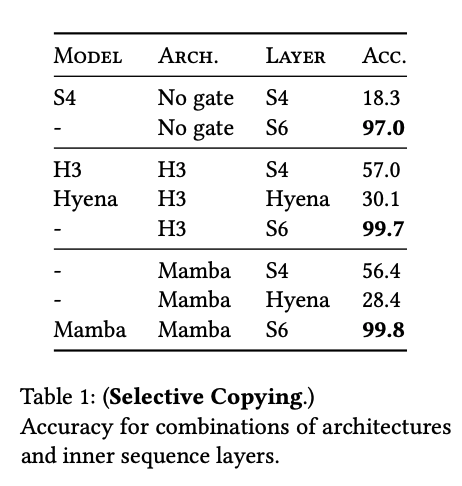

---

## 🔹Induction Heads Task

### 🎯 **Goal**

Test **associative recall** and **copying from history**, as inspired by mechanistic interpretability studies.

Example:

* Sequence: `"Harry Potter and Harry ..."`
* Task: Predict `"Potter"` after the second `"Harry"`

---

### 🧪 Experiment Setup

| Parameter            | Value                                                                                      |
| -------------------- | ------------------------------------------------------------------------------------------ |
| Model depth          | 2 layers                                                                                   |
| Sequence length      | 256 (train)                                                                                |
| Test lengths         | From 64 up to 1,048,576                                                                    |
| Vocab size           | 16                                                                                         |
| d\_model (Mamba)     | 64                                                                                         |
| d\_model (others)    | 128                                                                                        |
| Heads (Attention)    | 8                                                                                          |
| Positional encodings | Varied (for attention models)                                                              |
| Metric               | Accuracy over next-token prediction                                                        |
| Training details     | Likely cross-entropy loss, standard optimizer (e.g., AdamW) — full details in Appendix E.1 |

---

### ✅ Key Result

| Model              | Generalization                              |
| ------------------ | ------------------------------------------- |
| Attention          | Works well up to 2× train length            |
| S4 / S5            | Fails (can't associate tokens non-locally)  |
| Mamba (SSM+Gating) | **Perfect generalization** up to length 1M+ |

**Why?**
Because Mamba's **selective scan** acts like an **associative memory** — it learns to **memorize only the relevant past tokens** and **ignore spacing**, a behavior similar to what attention does via key-value matching.

---

### 🔍 Summary of Why Mamba Succeeds

* **Gating (SiLU-based modulation)** gives local non-linearity
* **State space layer** tracks temporal dependencies efficiently
* **Selective scan** learns **what to remember and when**, solving long-range dependency tasks without explicitly computing attention scores



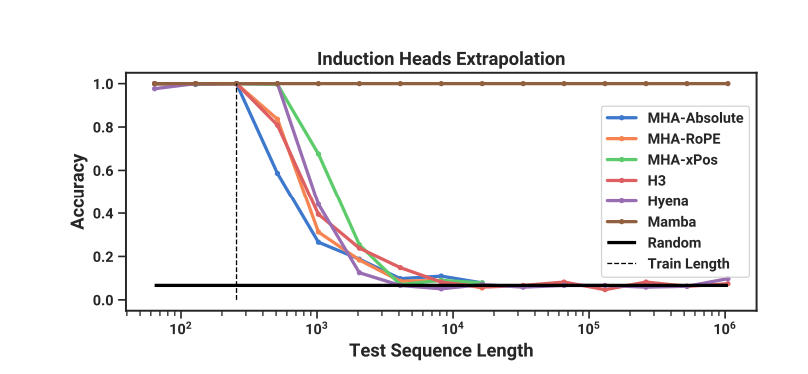

## 📚 Language Modeling – Summary of Mamba Results

We evaluate **Mamba** on autoregressive language modeling using the **Pile** dataset and GPT-3-scale model sizes. Key highlights:

### 🔍 Pretraining Setup
- Dataset: **Pile**
- Architecture: Mirrors **GPT-3** configuration
- Training follows Brown et al. (2020); details in Appendix E.2

### 📈 Scaling Laws
- Scaling laws describe how a model's performance improves as you increase its:
  * Model size (number of parameters)
  * Training dataset size
  * Compute budget (FLOPs)
- Compared against:
  - **Transformer** (GPT-3)
  - **Transformer++** (enhanced recipe with rotary embeddings, SwiGLU, RMSNorm, etc.)
  - Other **subquadratic architectures**: RWKV, RetNet, etc.
- Result: **Mamba matches Transformer++** performance across sizes (125M to 1.3B) under Chinchilla scaling laws.
- Especially effective at **longer sequence lengths**.
- Other recurrent models failed to scale to 8K context length due to inefficiencies (OOM, slow).


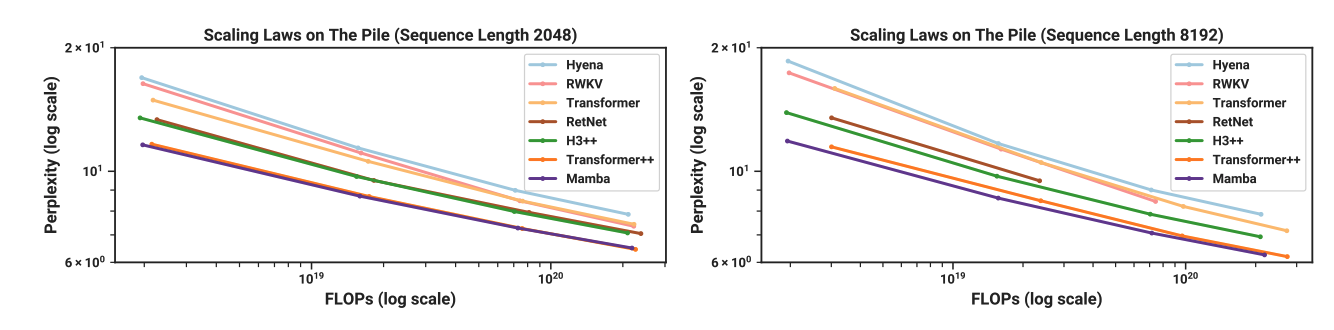



### 📊 Zero-Shot Downstream Evaluations
-💡 "Zero-shot" means:
  * The model is not trained on the task.
  * It only sees the task description and examples as part of the prompt.
  * Performance depends on generalization from pretraining.
- Mamba is evaluated on a broad suite of **zero-shot tasks**.
- Compared against open-source LMs: **Pythia** and **RWKV** (all trained on 300B tokens).
- Context lengths:
  - Mamba & Pythia: 2048
  - RWKV: 1024
- **Table 3 results**:
  - Mamba outperforms all baselines at **equal or smaller model size**.
  - Matches performance of models **twice its size** in many tasks.
  - Strong generalization and sample efficiency.

> 🏆 **Conclusion**: Mamba is the first attention-free model to match or outperform the strongest Transformer-based LMs at scale, particularly on long-context and zero-shot tasks.


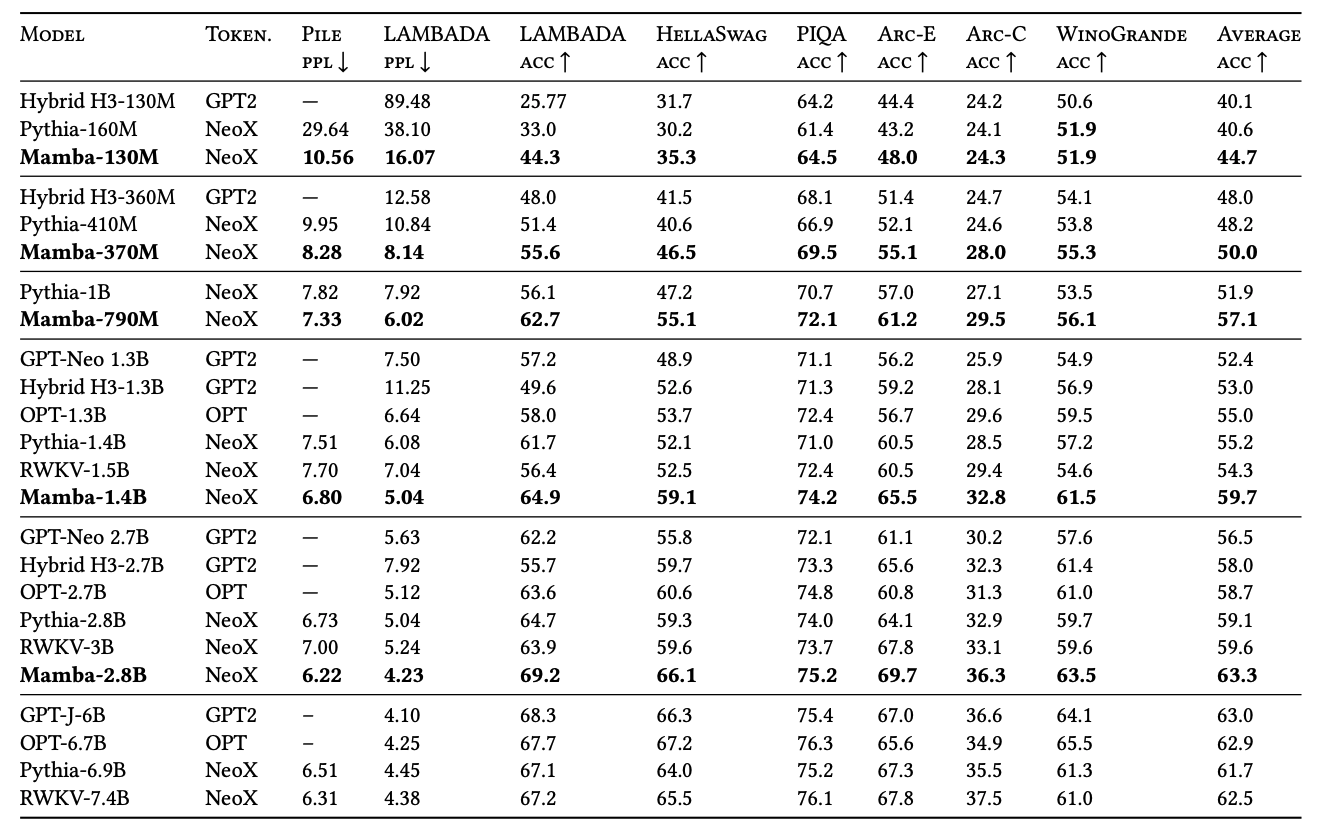

## 🧠 What is Jamba-1.5?

**Jamba-1.5** is a family of instruction-tuned large language models developed by AI21 Labs. It introduces a novel hybrid architecture that combines Transformer layers with Mamba (a type of Structured State Space Model) layers, integrated within a Mixture-of-Experts (MoE) framework. This design aims to achieve high throughput and low memory usage across varying context lengths, without compromising on model quality.([ResearchGate][2], [arXiv][3])

Two variants of the model have been released:([ResearchGate][2])

* **Jamba-1.5-Large**: Featuring 94 billion active parameters.
* **Jamba-1.5-Mini**: Featuring 12 billion active parameters.([ResearchGate][2])

Both models support an effective context length of up to 256,000 tokens, which is among the largest for open-weight models.([ResearchGate][2])

---

## 🧱 Jamba-1.5 Model Architecture


Jamba-1.5-Large builds on the original **Jamba hybrid decoder** by combining:

- **Transformer layers** (attention-based)
- **Mamba layers** (state-space modeling)
- **Mixture-of-Experts (MoE)** modules

This architecture achieves a balance of **throughput**, **memory efficiency**, and **model quality**.

### 🔢 Key Configuration (Jamba-1.5-Large):
- **Total parameters**: 398B (94B active)
- **Blocks**: 9 blocks, each with `l=8` layers
- **Layer ratio**: 1 Transformer : 7 Mamba layers
- **MoE**: Every 2nd layer replaces MLP with MoE
  - 16 experts total (`n=16`)
  - Top-2 selected per token (`K=2`)
- **Hidden dimension**: 8192
- **Attention heads**: 64 (with 8 KV heads)

### 🧠 Efficiency:
- Runs on **8×80GB GPUs**
- Supports up to **256K context length**
- ~10× smaller KV cache usage compared to similarly sized models (e.g., Mixtral, LLaMA-3)
---

## 🏗️ Architectural Highlights

The architecture of Jamba-1.5 is characterized by:

* **Hybrid Layer Composition**: Interleaving Transformer and Mamba layers within the model blocks.
* **Mixture-of-Experts (MoE)**: Incorporating multiple expert networks, with a gating mechanism that selects the top experts for each input token, enhancing model capacity without a proportional increase in computational cost.
* **ExpertsInt8 Quantization**: A novel quantization technique introduced to reduce memory footprint and enable efficient inference, particularly beneficial for deploying large models like Jamba-1.5-Large on hardware with limited resources. ([ResearchGate][2])

---

## ⚙️ Performance and Efficiency

Jamba-1.5 models have demonstrated impressive performance metrics:

* **High Throughput**: Achieving faster inference times compared to traditional Transformer models of similar sizes.
* **Low Memory Usage**: Thanks to the hybrid architecture and quantization techniques, the models require less memory, facilitating deployment on a wider range of hardware configurations.
* **Long-Context Handling**: Effectively managing and utilizing long context windows up to 256K tokens, which is particularly advantageous for tasks requiring understanding of extensive textual data.([Analytics Vidhya][4])

---

## 🔍 Accessing Jamba-1.5 Models

The Jamba-1.5 models are publicly available and can be accessed through:

* **Hugging Face**:

  * [Jamba-1.5-Large](https://huggingface.co/ai21labs/AI21-Jamba-1.5-Large)
  * [Jamba-1.5-Mini](https://huggingface.co/ai21labs/AI21-Jamba-1.5-Mini)
* **AI21 Labs' API**: Providing endpoints for integrating Jamba-1.5 capabilities into applications.

These resources enable researchers and developers to experiment with and deploy Jamba-1.5 models for various natural language processing tasks.


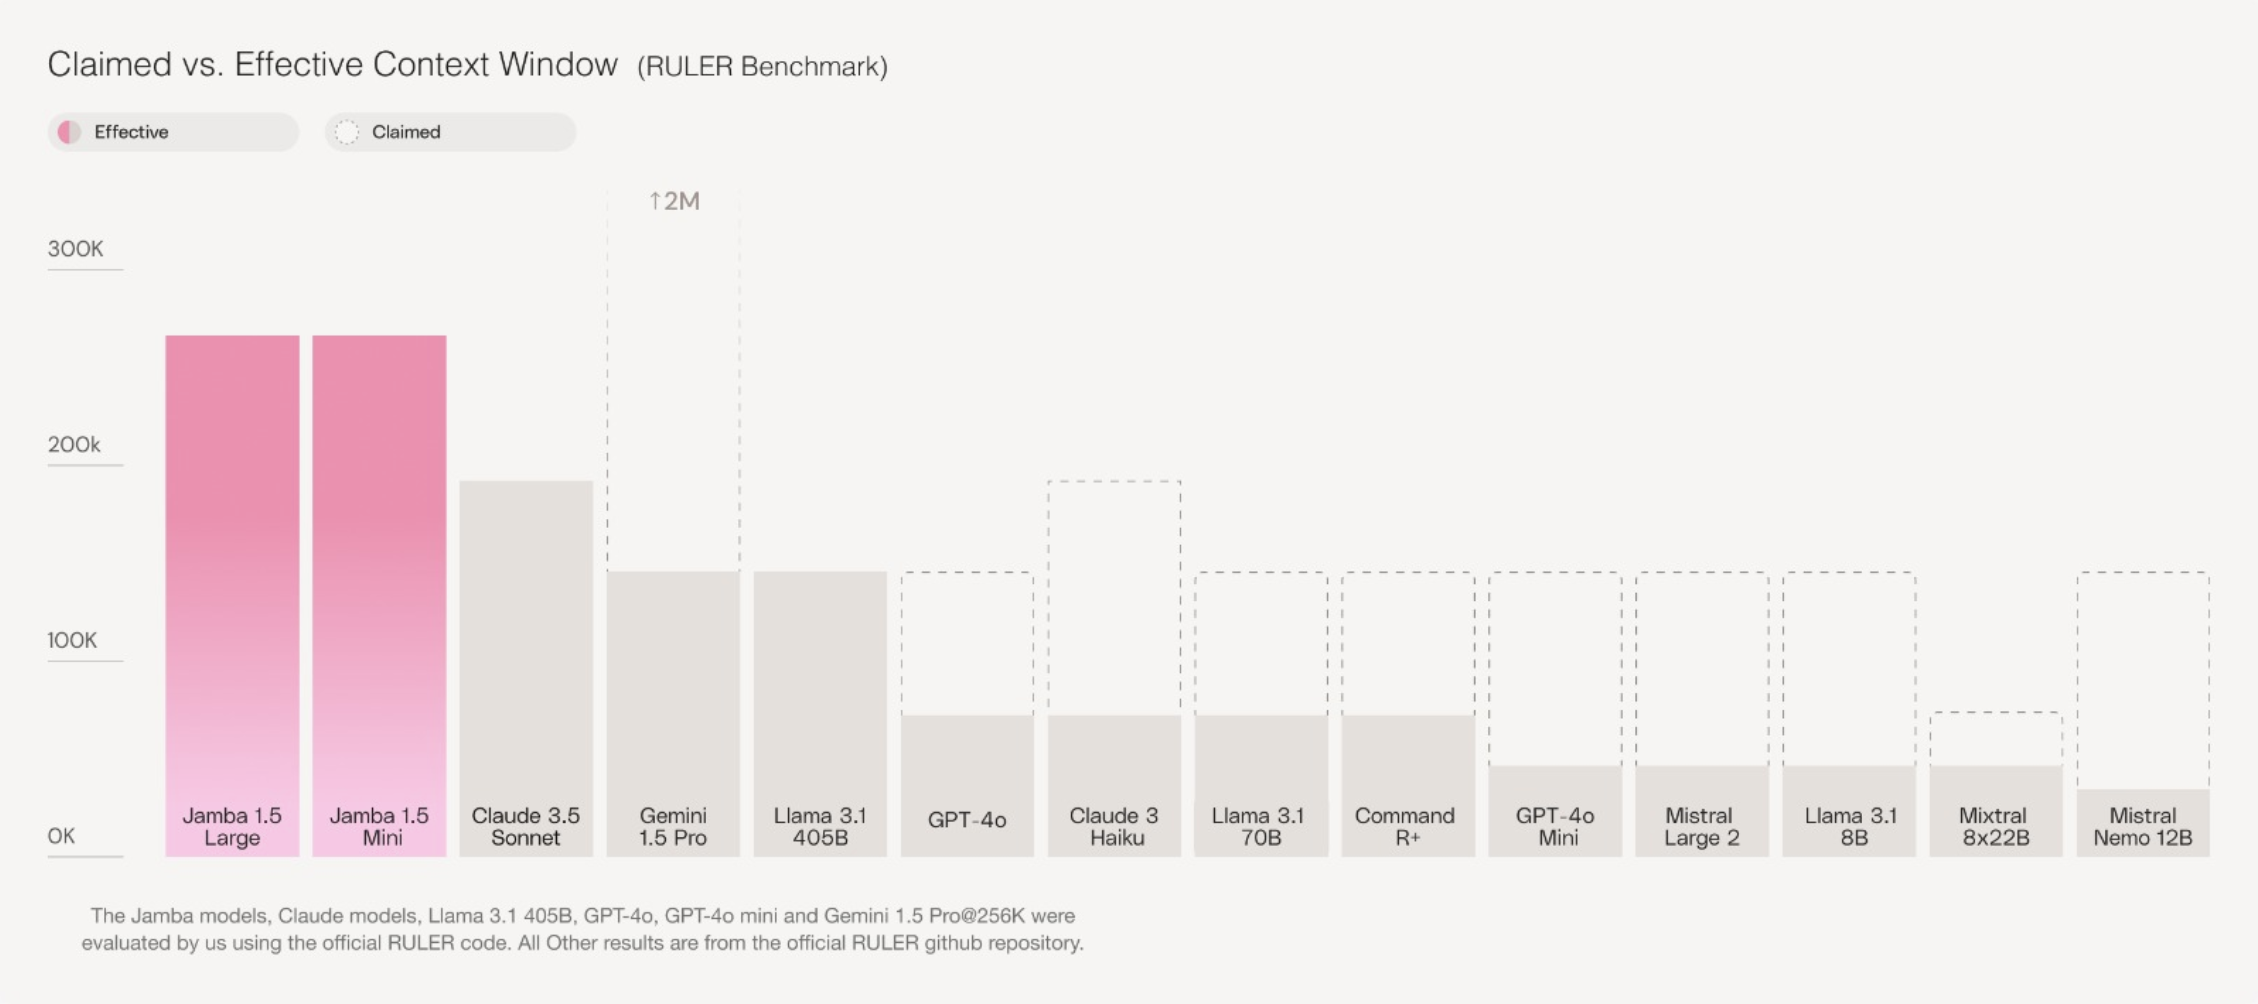

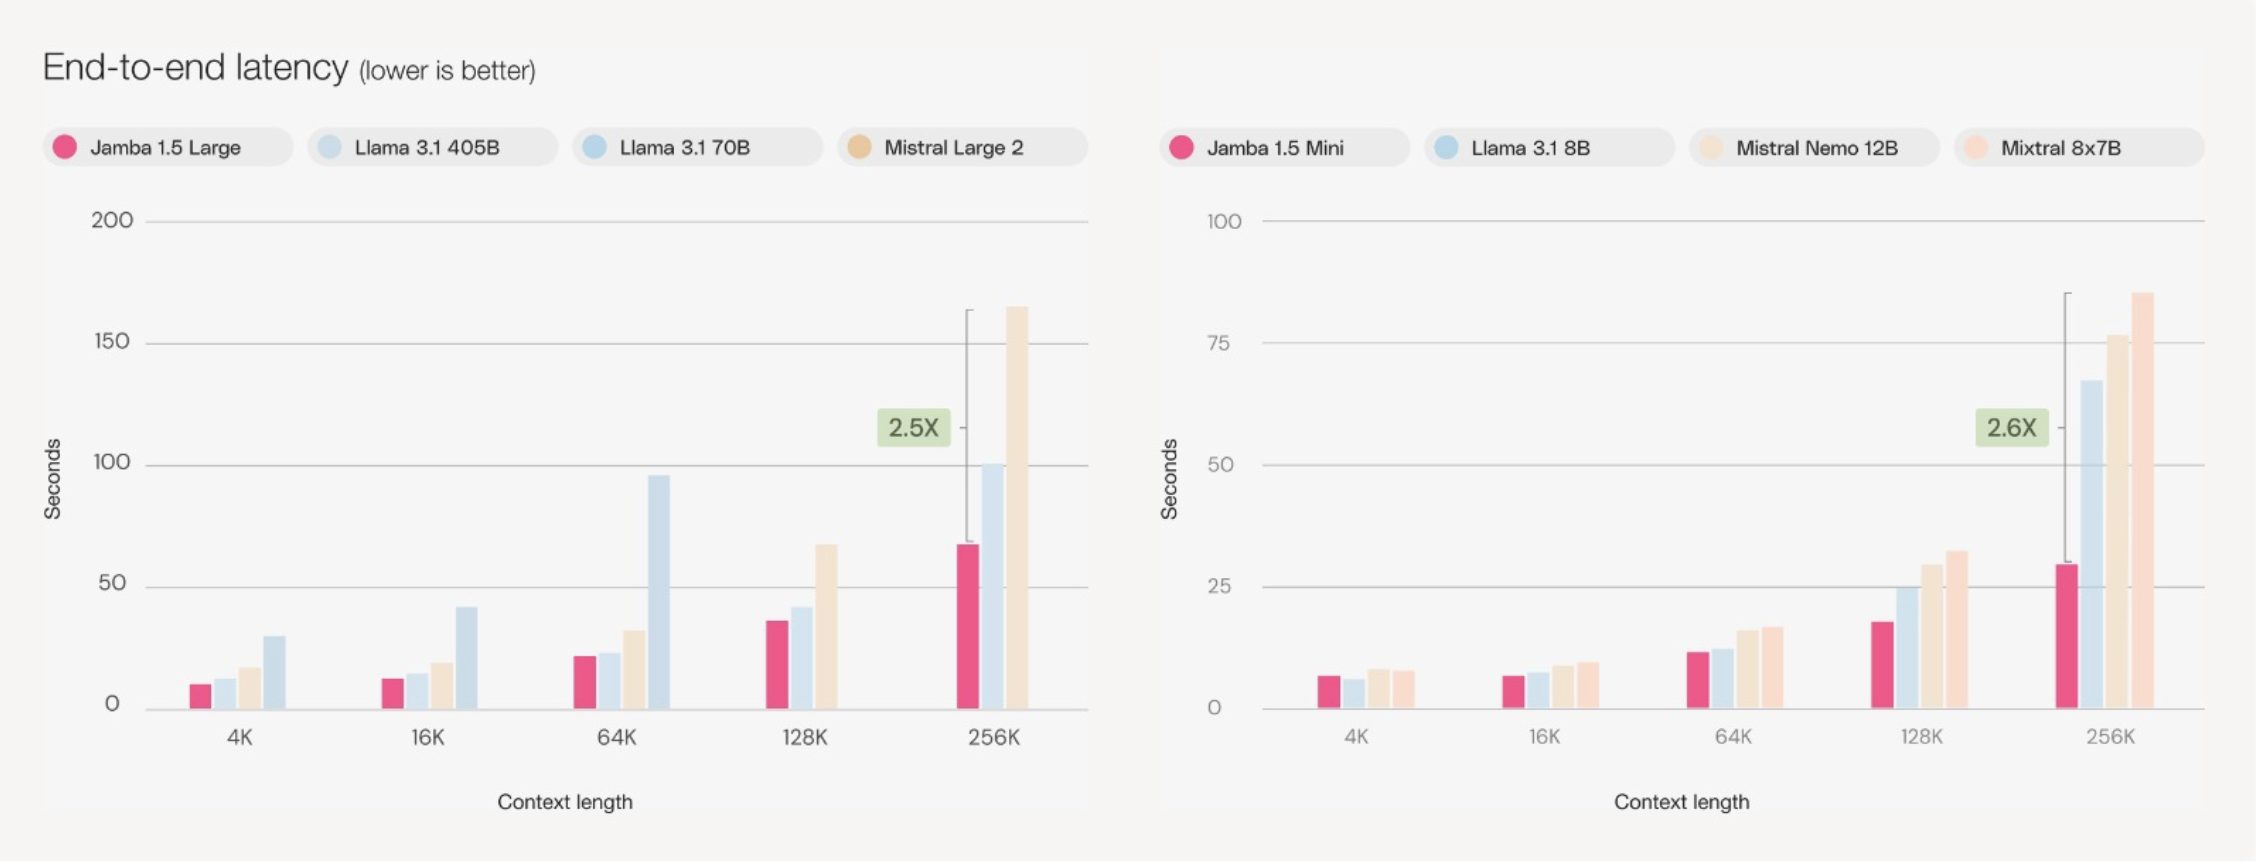

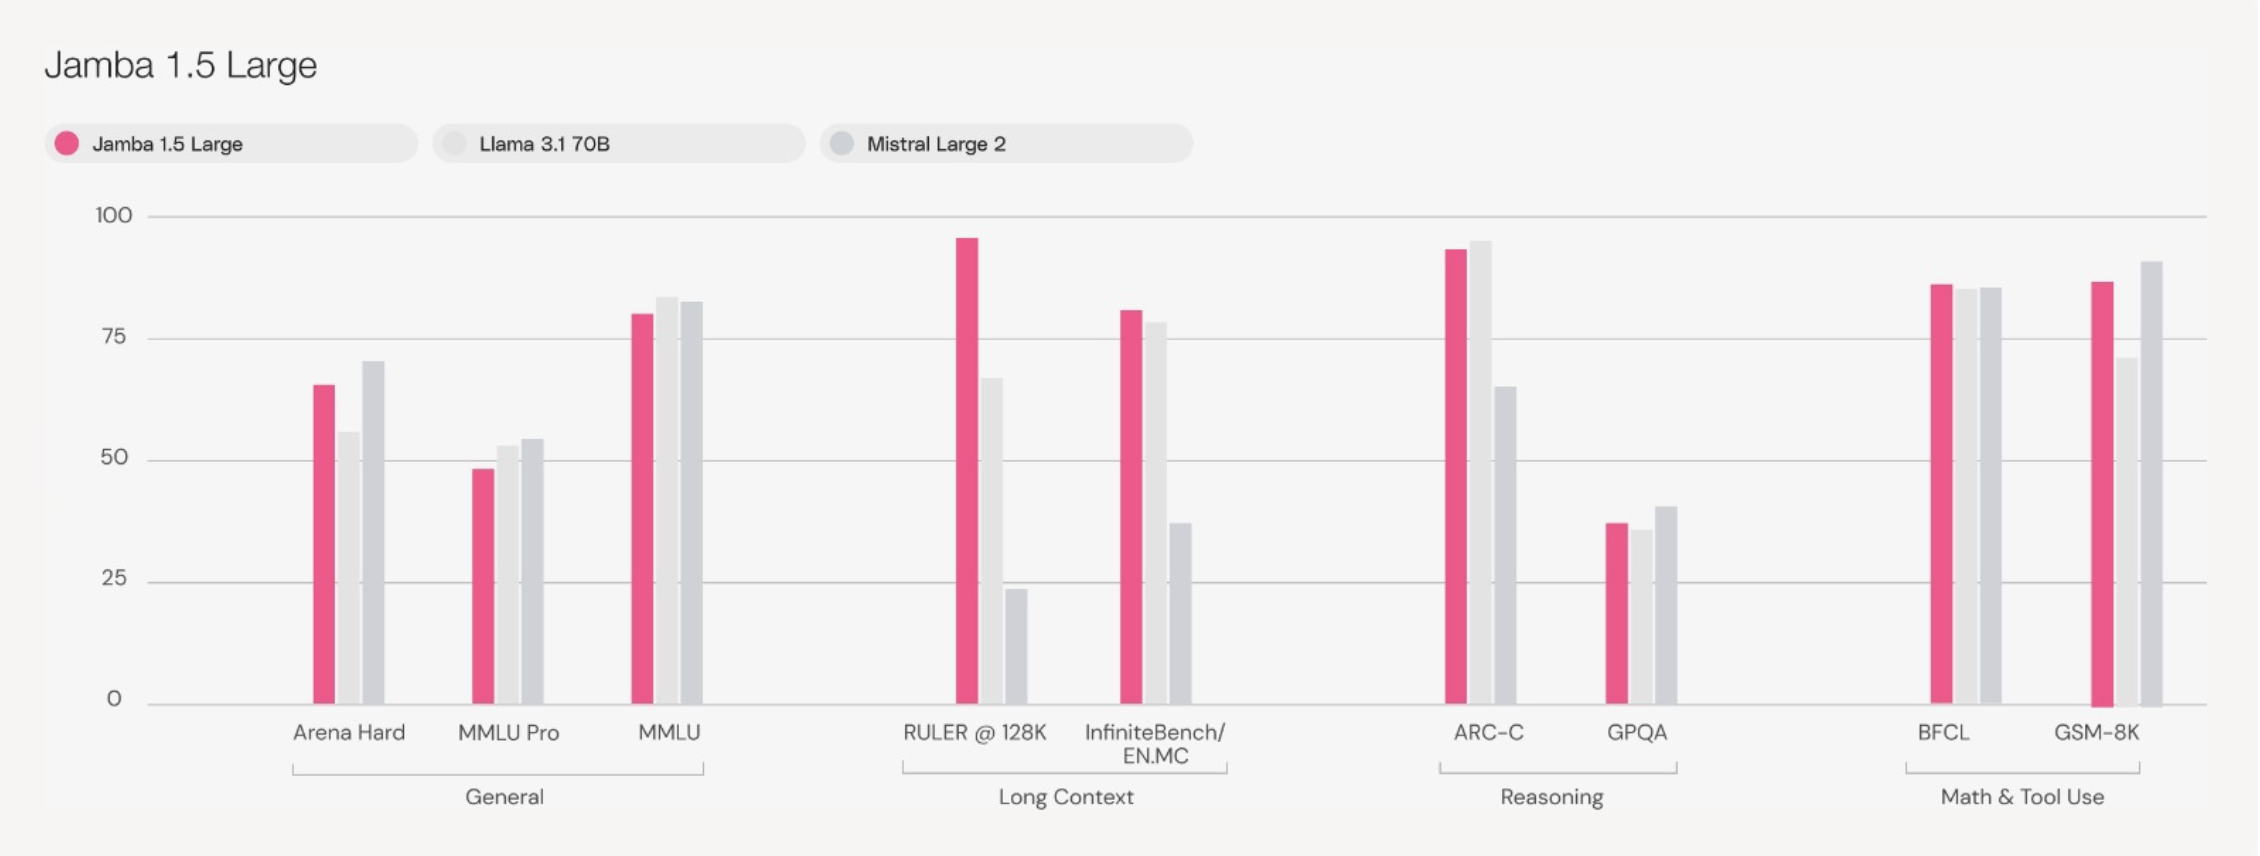

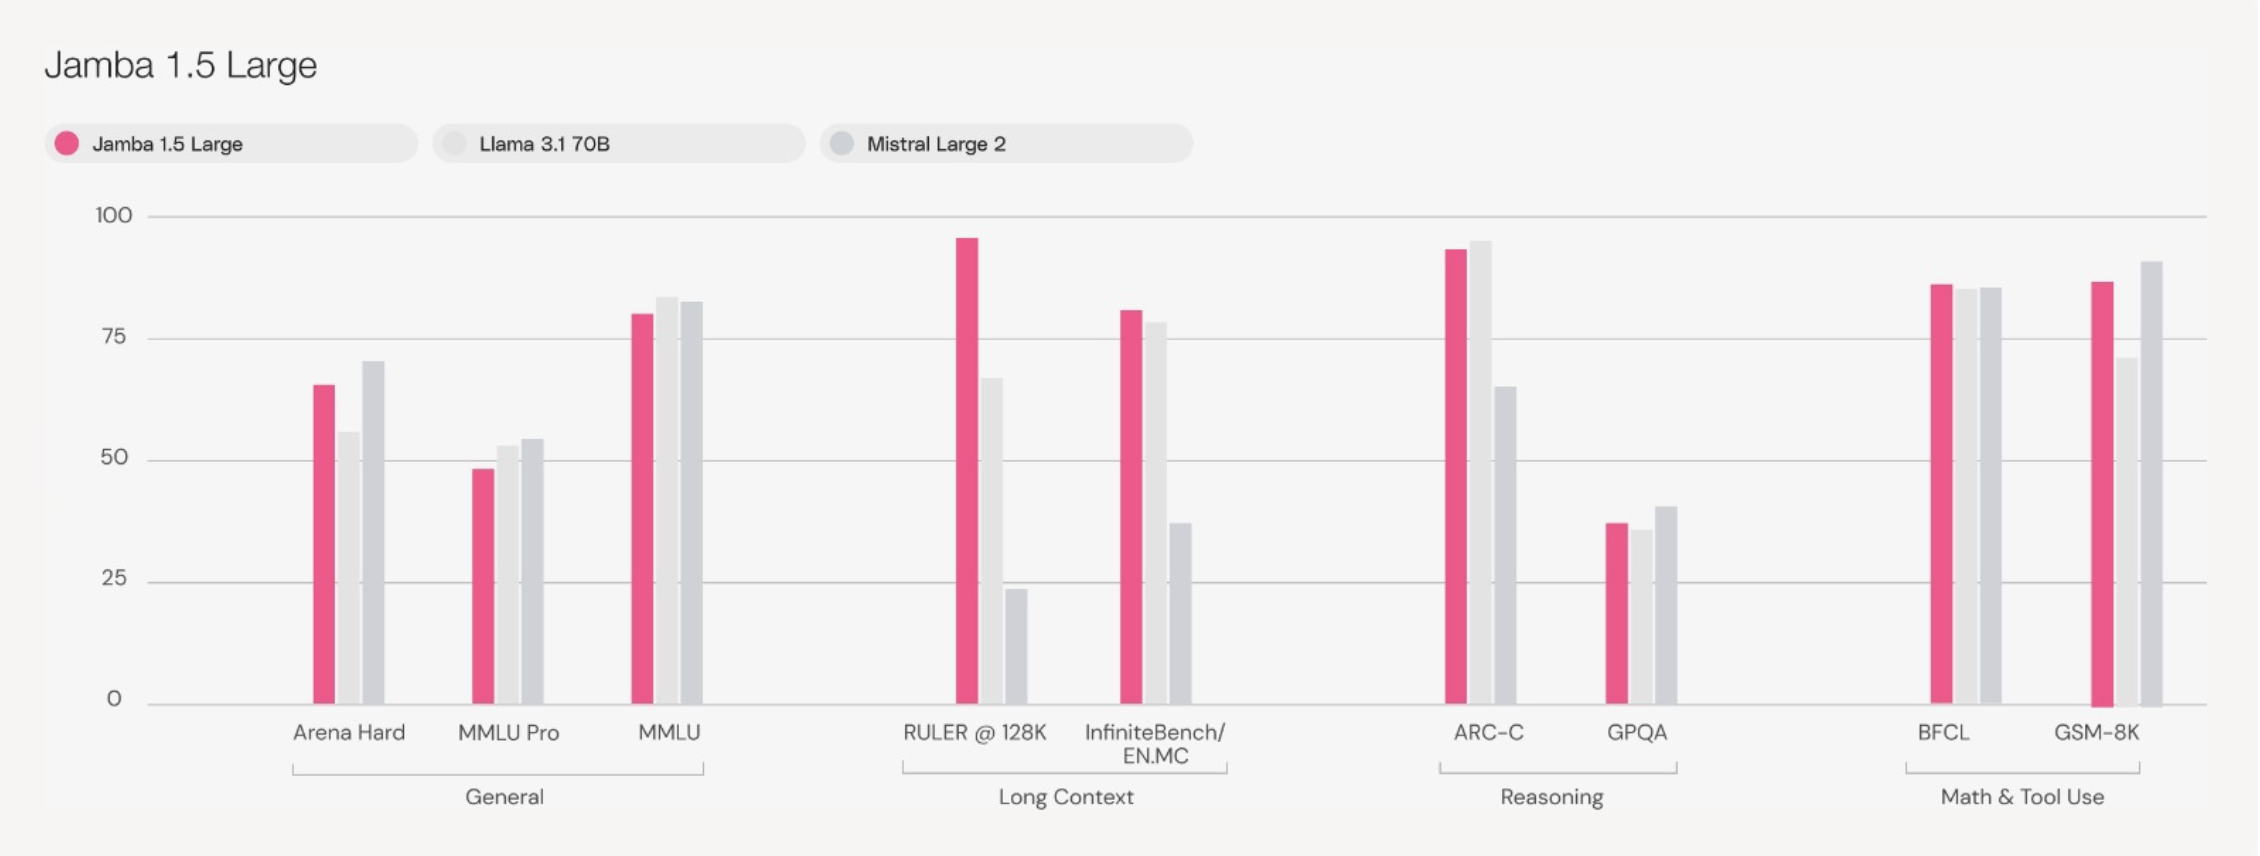